In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

In [2]:
df1 = pd.read_csv('cells_concat_raw_1.csv', index_col=0)
df2 = pd.read_csv('cells_concat_raw_2.csv', index_col=0)
df = pd.concat([df1, df2], ignore_index=True)

In [3]:
df['directA_cell_delta'] = df['directA_cell_after'] - df['directA_cell']

In [4]:
df['donor_cell_delta'] = df['D_cell_after'] - df['D_cell']
df['acceptor_corr_cell_delta'] = df['A_cell_corr_after'] - df['A_cell_corr']

In [5]:
### Data filters

## Removing cells dominated by background and cells reaching saturation
df = df[df['directA_cell_max'] >= 400] 
df = df[df['directA_cell_max'] <= 65000] 

## Removing cells that have a large change in directA intensity after perturbation (shouldn't happen to healthy cells)
df = df[df['directA_cell_delta_ratio'] > 0.8]
df = df[df['directA_cell_delta_ratio'] < 1.1]
## Removing cells that are too circular (likely dying)
df = df[df['circ_cell_original'] < 0.8]
df = df[df['circ_cell_original'] > 0.3]
## Removing cells that have a very large nucleus in comparison to total area (likely dying), or they are segmented incorrectly (common in condensate formers)
df = df[df['nuc_area_ratio'] < .75]
df = df[df['nuc_area_ratio'] > .05]
## Removing cells with negative A_cell_corr - weird stuff going on or too close to background
df = df[df['A_cell_corr'] > 0]
## removing very small cells and/or debris
df = df[df['area_cell'] > 2000]
df = df[df['area_cell'] < 25000]

df = df[df['area_nuc'] < 5000]
df = df[df['area_nuc'] > 600]

In [22]:
## Only keeping cells that we believe are not experiencing dominant INTER-molecular FRET effects (only INTRA)
df = df[df['log_directA_cell'] < 3.25]
df = df[df['log_directA_cell'] > 2]

In [6]:
def plot_filter_histograms(df, column, bins=100, xlim=None, ylim=None, 
                           filter_range=None, color='blue', figsize_per_plot=(3, 2),
                           xlabel=None, ylabel='Count', ncols=4, normalize=False):
    """
    Create histogram subplots for each construct in the dataframe.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the data
    column : str
        Column name to plot histograms for
    bins : int or array-like, default=100
        Number of bins or bin edges for histogram
    xlim : tuple or None, default=None
        X-axis limits (min, max). If None, uses data range
    ylim : tuple or None, default=None
        Y-axis limits (min, max). If None, uses automatic scaling
    filter_range : tuple or None, default=None
        (left, right) values for filter cutoffs. Bars outside this range
        will be colored grey with dashed lines at cutoff positions
    color : str, default='blue'
        Color for bars within the filter range
    figsize_per_plot : tuple, default=(3, 2)
        Size of each individual subplot (width, height)
    xlabel : str or None, default=None
        X-axis label. If None, uses column name
    ylabel : str, default='Count'
        Y-axis label
    ncols : int, default=4
        Number of columns in the subplot grid
    normalize : bool, default=False
        If True, normalize histogram to probability density
    
    Returns:
    --------
    fig, axes : matplotlib figure and axes objects
    """
    
    # Get unique constructs
    constructs = sorted(df['construct'].unique())
    n = len(constructs)
    
    if n == 0:
        raise ValueError("No constructs found in df.")
    
    # Calculate grid dimensions
    nrows = math.ceil(n / ncols)
    
    # Create figure
    fig, axes = plt.subplots(nrows, ncols, 
                            figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
                            sharex=True, sharey=True)
    axes = axes.flatten() if n > 1 else [axes]
    
    # Set default xlabel if not provided
    if xlabel is None:
        xlabel = column
    
    # Update ylabel if normalizing
    if normalize and ylabel == 'Count':
        ylabel = 'Probability Density'
    
    # Determine bin edges if not provided as array
    if isinstance(bins, int):
        # Get overall data range for consistent bins
        all_data = df[column].dropna()
        if len(all_data) == 0:
            raise ValueError(f"No valid data found in column '{column}'")
        
        if xlim is not None:
            bin_edges = np.linspace(xlim[0], xlim[1], bins + 1)
        else:
            bin_edges = np.linspace(all_data.min(), all_data.max(), bins + 1)
    else:
        bin_edges = bins
    
    # Plot histogram for each construct
    for i, construct in enumerate(constructs):
        ax = axes[i]
        
        # Get data for this construct
        construct_data = df[df['construct'] == construct][column].dropna()
        
        if len(construct_data) > 0:
            # Calculate histogram
            counts, edges = np.histogram(construct_data, bins=bin_edges, density=normalize)
            bin_centers = (edges[:-1] + edges[1:]) / 2
            bin_width = edges[1] - edges[0]
            
            # Determine colors for each bar
            if filter_range is not None:
                left, right = filter_range
                bar_colors = [color if left <= bc <= right else 'grey' 
                            for bc in bin_centers]
            else:
                bar_colors = [color] * len(counts)
            
            # Plot bars
            ax.bar(bin_centers, counts, width=bin_width * 0.9, 
                  color=bar_colors, edgecolor='black', linewidth=0.5)
            
            # Add dashed lines at filter cutoffs
            if filter_range is not None:
                left, right = filter_range
                ax.axvline(left, color='grey', linestyle='--', linewidth=1.5, alpha=0.7)
                ax.axvline(right, color='grey', linestyle='--', linewidth=1.5, alpha=0.7)
            
            # Set title
            ax.set_title(f"Construct #{construct} (n={len(construct_data)})", 
                        fontsize=9, fontweight='bold')
            
            ax.axvline(0, color='black', linestyle='-', linewidth=1)

            # Set axis limits
            if xlim is not None:
                ax.set_xlim(xlim)
            if ylim is not None:
                ax.set_ylim(ylim)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=10)
        
        # Add axis labels only for leftmost column and bottom row
        if i % ncols == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        if i // ncols == nrows - 1:
            ax.set_xlabel(xlabel, fontsize=9)
        
        # Add grid
        ax.grid(True, linestyle=':', alpha=0.3, axis='y')
        ax.tick_params(labelsize=8)
    
    # Turn off unused subplots
    for j in range(n, nrows * ncols):
        axes[j].axis('off')
    
    plt.tight_layout()
    
    return fig, axes

(<Figure size 1200x2000 with 40 Axes>,
 array([<Axes: title={'center': 'Construct #1.0 (n=813)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #2.0 (n=275)'}>,
        <Axes: title={'center': 'Construct #3.0 (n=1037)'}>,
        <Axes: title={'center': 'Construct #4.0 (n=563)'}>,
        <Axes: title={'center': 'Construct #5.0 (n=651)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #6.0 (n=391)'}>,
        <Axes: title={'center': 'Construct #7.0 (n=625)'}>,
        <Axes: title={'center': 'Construct #8.0 (n=427)'}>,
        <Axes: title={'center': 'Construct #9.0 (n=695)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #10.0 (n=683)'}>,
        <Axes: title={'center': 'Construct #11.0 (n=563)'}>,
        <Axes: title={'center': 'Construct #12.0 (n=290)'}>,
        <Axes: title={'center': 'Construct #13.0 (n=695)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #14.0 (n=713)

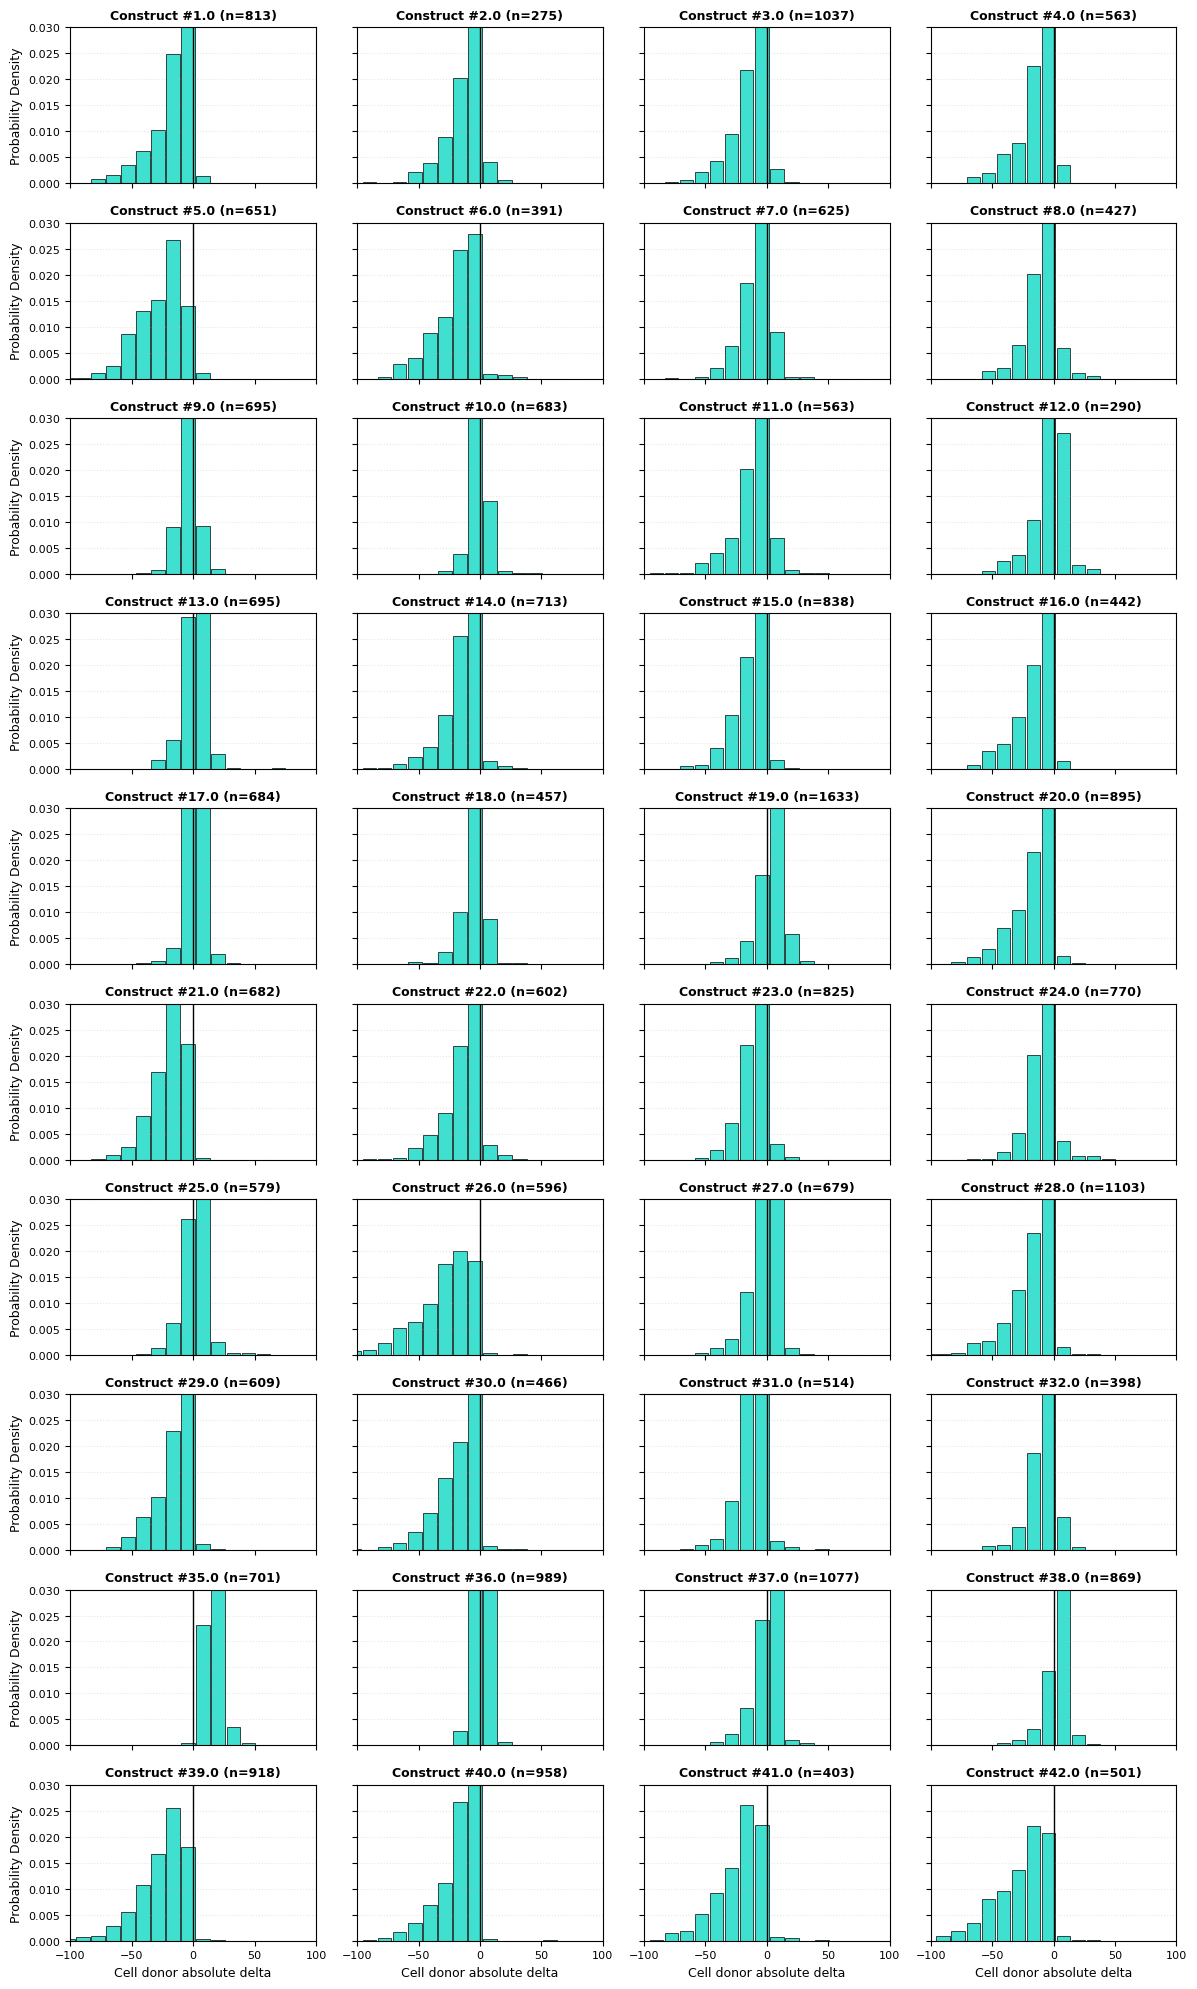

In [33]:
bins=np.linspace(-500,100,50)
plot_filter_histograms(df, column='donor_cell_delta', bins=bins , xlim=(-100, 100),
                       filter_range=(-30000, 3000), ylim=(0, .03), color='turquoise', figsize_per_plot=(3, 2),
                       xlabel='Cell donor absolute delta', ylabel='Count', ncols=4, normalize=True)

(<Figure size 1200x2000 with 40 Axes>,
 array([<Axes: title={'center': 'Construct #1.0 (n=813)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #2.0 (n=275)'}>,
        <Axes: title={'center': 'Construct #3.0 (n=1037)'}>,
        <Axes: title={'center': 'Construct #4.0 (n=563)'}>,
        <Axes: title={'center': 'Construct #5.0 (n=651)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #6.0 (n=391)'}>,
        <Axes: title={'center': 'Construct #7.0 (n=625)'}>,
        <Axes: title={'center': 'Construct #8.0 (n=427)'}>,
        <Axes: title={'center': 'Construct #9.0 (n=695)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #10.0 (n=683)'}>,
        <Axes: title={'center': 'Construct #11.0 (n=563)'}>,
        <Axes: title={'center': 'Construct #12.0 (n=290)'}>,
        <Axes: title={'center': 'Construct #13.0 (n=695)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #14.0 (n=713)

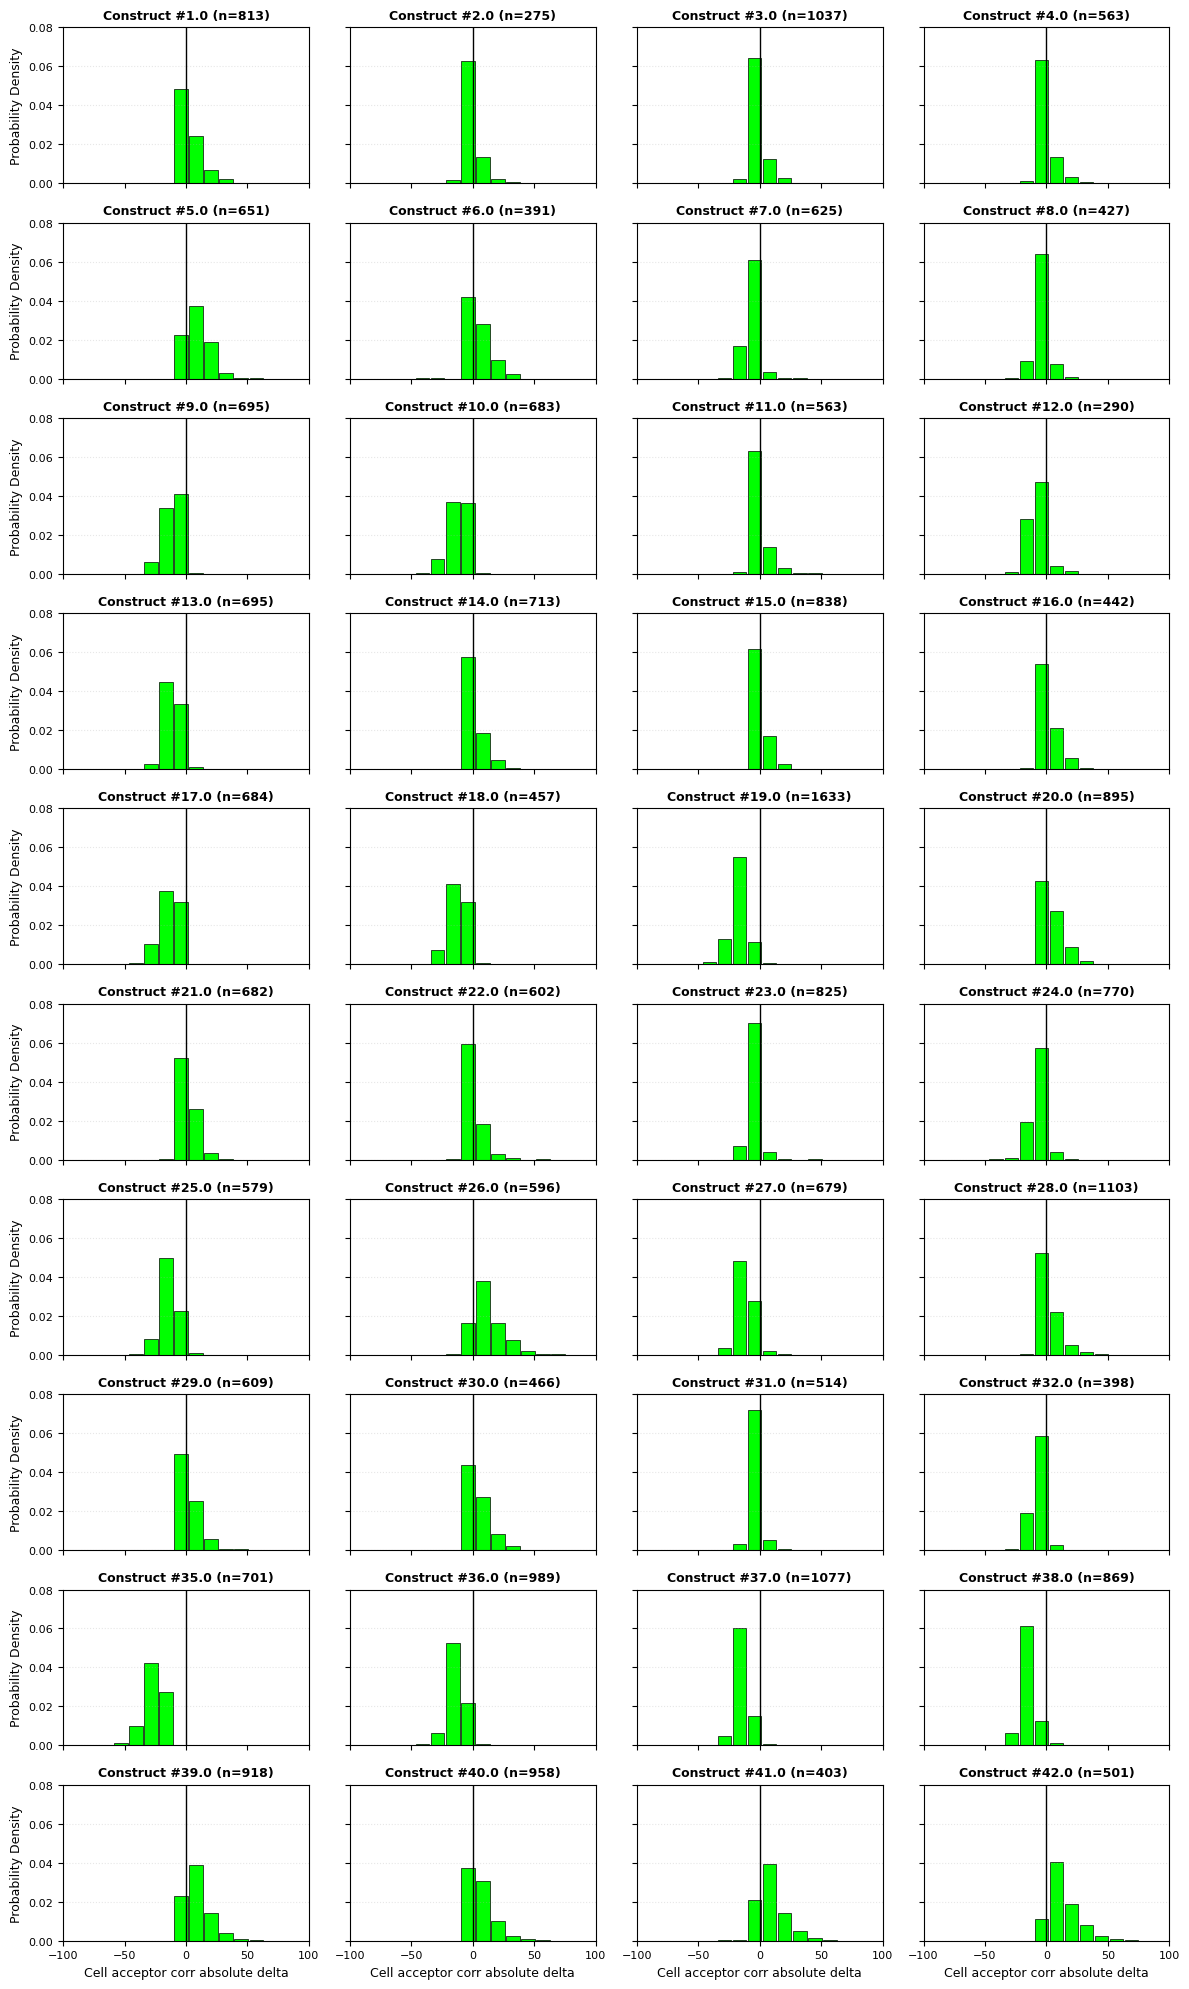

In [31]:
plot_filter_histograms(df, column='acceptor_corr_cell_delta', bins=bins, xlim=(-100, 100),
                       filter_range=(-30000, 3000), ylim=(0, .08), color='lime', figsize_per_plot=(3, 2),
                       xlabel='Cell acceptor corr absolute delta', ylabel='Count', ncols=4, normalize=True)

(<Figure size 1200x2000 with 40 Axes>,
 array([<Axes: title={'center': 'Construct #1.0 (n=813)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #2.0 (n=275)'}>,
        <Axes: title={'center': 'Construct #3.0 (n=1037)'}>,
        <Axes: title={'center': 'Construct #4.0 (n=563)'}>,
        <Axes: title={'center': 'Construct #5.0 (n=651)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #6.0 (n=391)'}>,
        <Axes: title={'center': 'Construct #7.0 (n=625)'}>,
        <Axes: title={'center': 'Construct #8.0 (n=427)'}>,
        <Axes: title={'center': 'Construct #9.0 (n=695)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #10.0 (n=683)'}>,
        <Axes: title={'center': 'Construct #11.0 (n=563)'}>,
        <Axes: title={'center': 'Construct #12.0 (n=290)'}>,
        <Axes: title={'center': 'Construct #13.0 (n=695)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #14.0 (n=713)

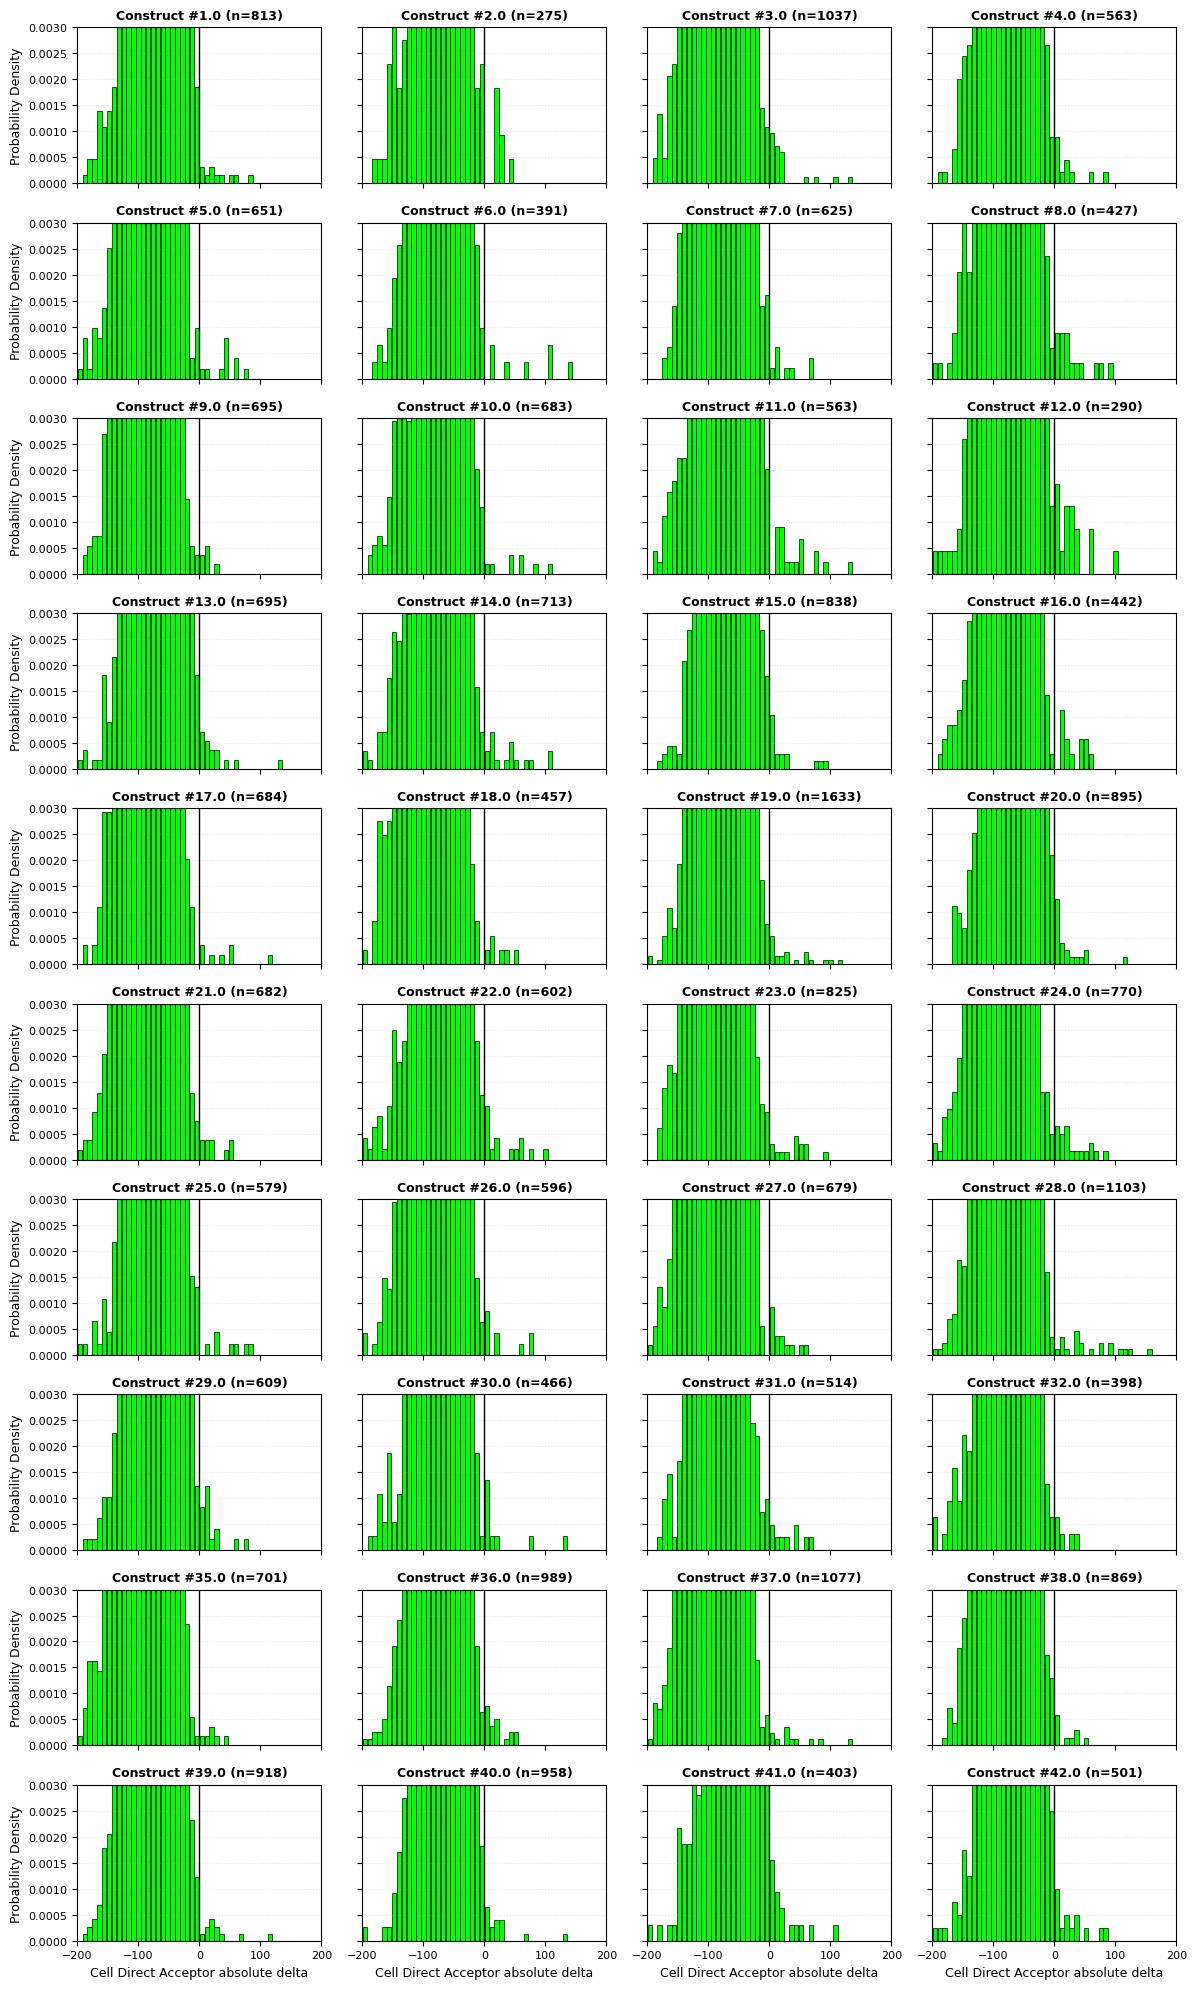

In [28]:
plot_filter_histograms(df, column='directA_cell_delta', bins=50, xlim=(-200, 200),
                       filter_range=(-30000, 3000), ylim=(0, .003),color='lime', figsize_per_plot=(3, 2),
                       xlabel='Cell Direct Acceptor absolute delta', ylabel='Count', ncols=4, normalize=True)

(<Figure size 1200x2000 with 40 Axes>,
 array([<Axes: title={'center': 'Construct #1.0 (n=3346)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #2.0 (n=1230)'}>,
        <Axes: title={'center': 'Construct #3.0 (n=4354)'}>,
        <Axes: title={'center': 'Construct #4.0 (n=2026)'}>,
        <Axes: title={'center': 'Construct #5.0 (n=3263)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #6.0 (n=2291)'}>,
        <Axes: title={'center': 'Construct #7.0 (n=2781)'}>,
        <Axes: title={'center': 'Construct #8.0 (n=2359)'}>,
        <Axes: title={'center': 'Construct #9.0 (n=4282)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #10.0 (n=2741)'}>,
        <Axes: title={'center': 'Construct #11.0 (n=2206)'}>,
        <Axes: title={'center': 'Construct #12.0 (n=1301)'}>,
        <Axes: title={'center': 'Construct #13.0 (n=2646)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #

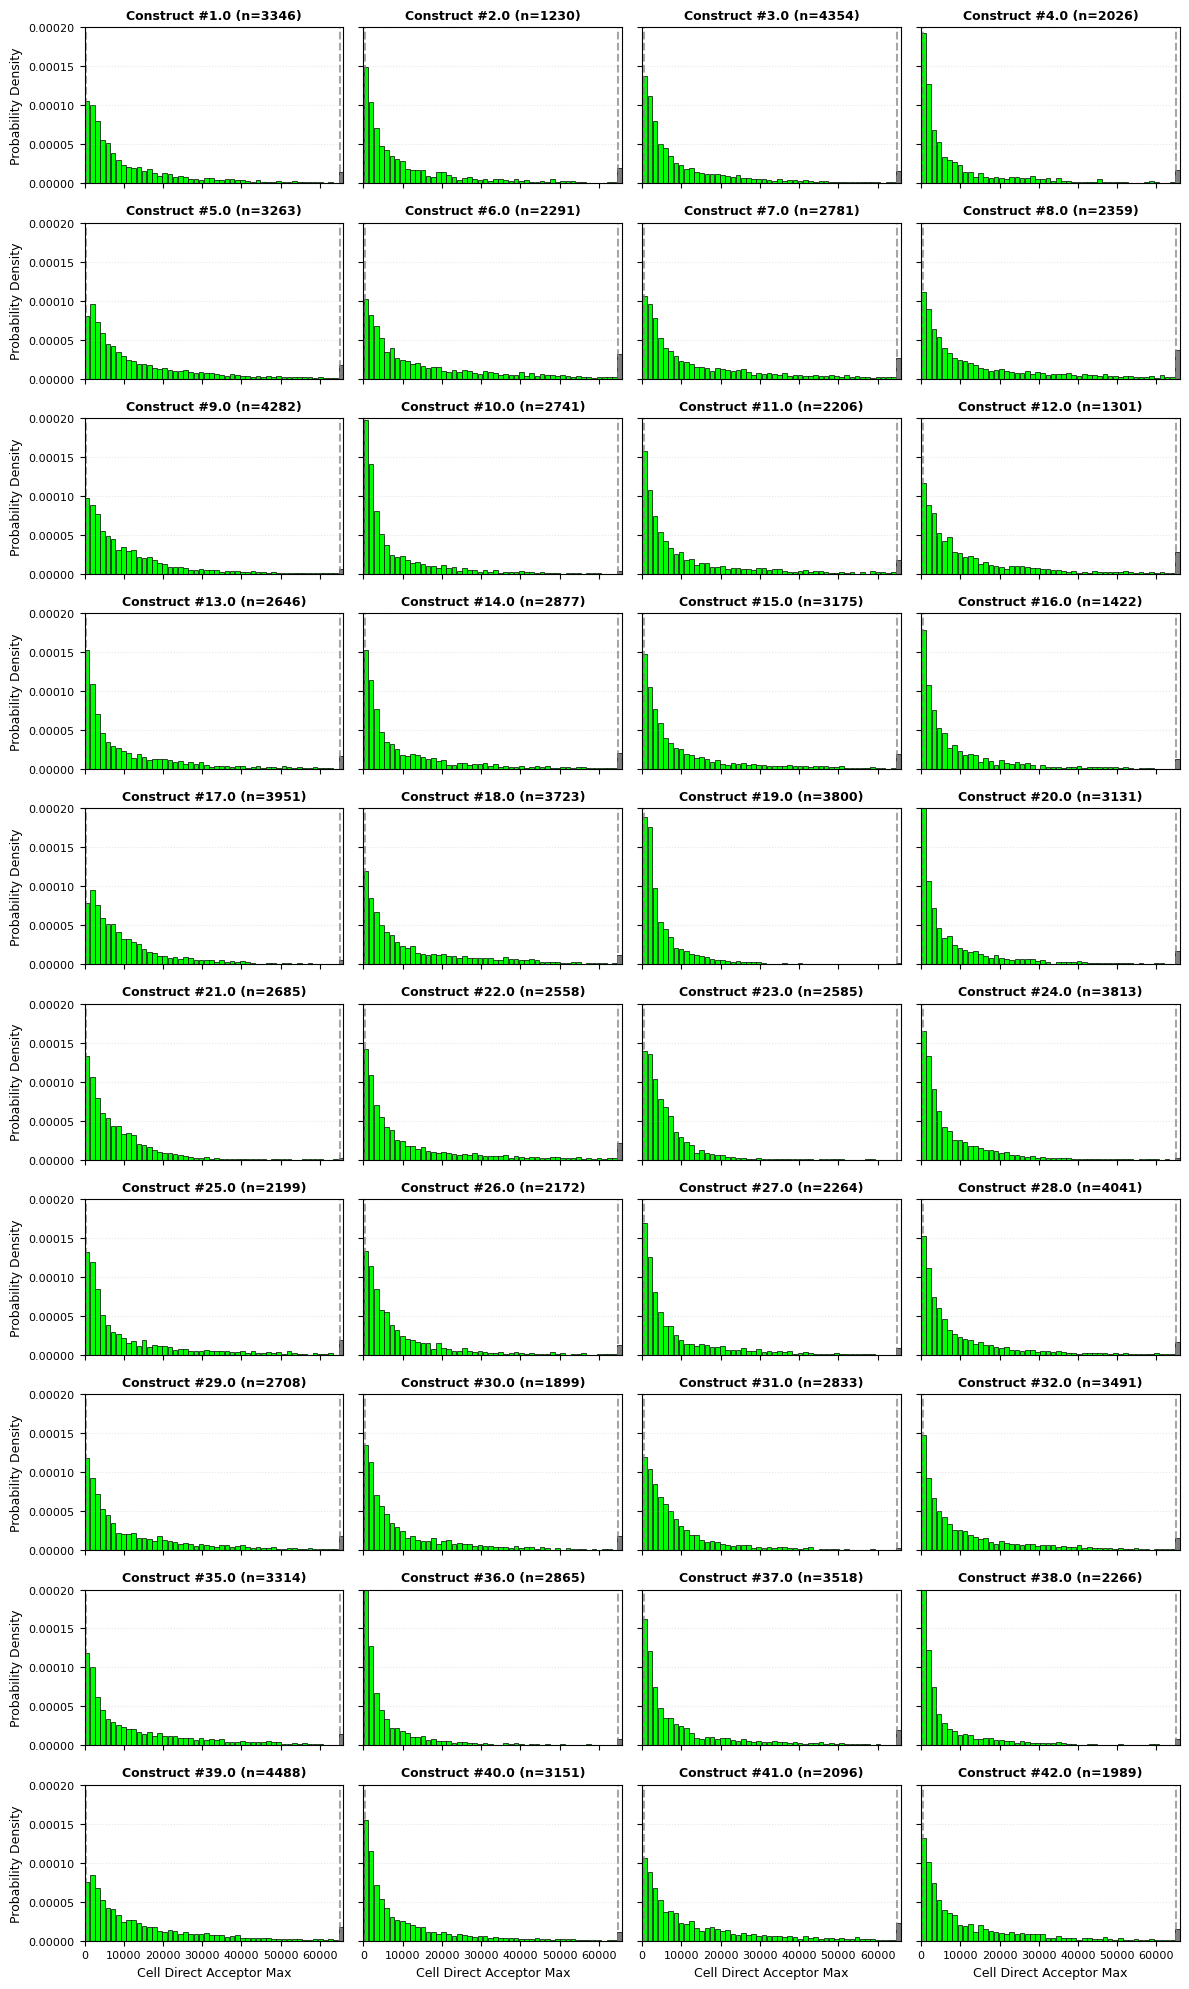

In [4]:
plot_filter_histograms(df, column='directA_cell_max', bins=50, xlim=(0, 66000), ylim=(0, .0002),
                       filter_range=(400, 65000), color='lime', figsize_per_plot=(3, 2),
                       xlabel='Cell Direct Acceptor Max', ylabel='Count', ncols=4, normalize=True)

(<Figure size 1200x2000 with 40 Axes>,
 array([<Axes: title={'center': 'Construct #1.0 (n=813)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #2.0 (n=275)'}>,
        <Axes: title={'center': 'Construct #3.0 (n=1037)'}>,
        <Axes: title={'center': 'Construct #4.0 (n=563)'}>,
        <Axes: title={'center': 'Construct #5.0 (n=651)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #6.0 (n=391)'}>,
        <Axes: title={'center': 'Construct #7.0 (n=625)'}>,
        <Axes: title={'center': 'Construct #8.0 (n=427)'}>,
        <Axes: title={'center': 'Construct #9.0 (n=695)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #10.0 (n=683)'}>,
        <Axes: title={'center': 'Construct #11.0 (n=563)'}>,
        <Axes: title={'center': 'Construct #12.0 (n=290)'}>,
        <Axes: title={'center': 'Construct #13.0 (n=695)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #14.0 (n=713)

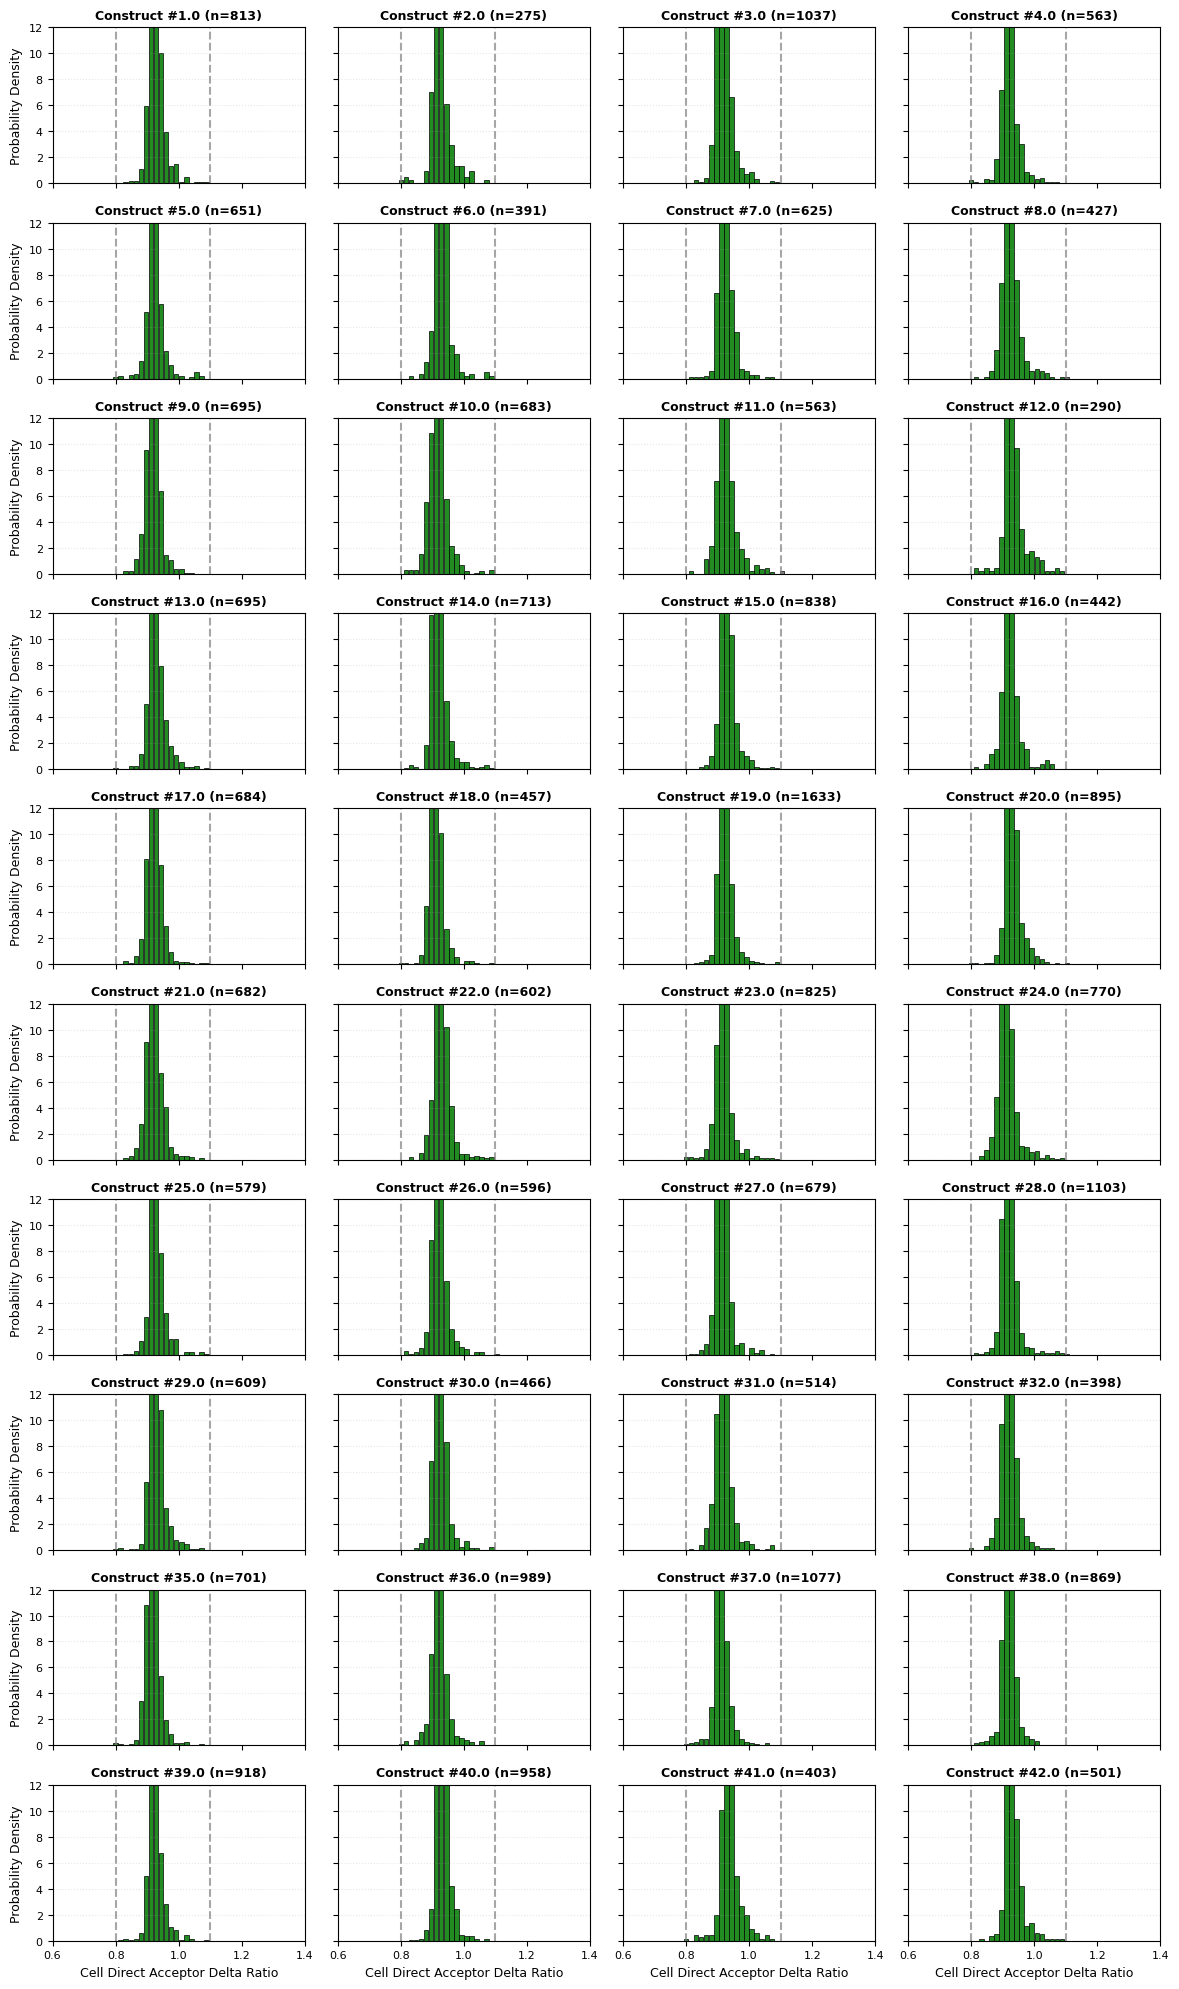

In [26]:
plot_filter_histograms(df, column='directA_cell_delta_ratio', bins=50, xlim=(.6, 1.4), ylim=(0, 12),
                       filter_range=(0.8, 1.1), color='forestgreen', figsize_per_plot=(3, 2),
                       xlabel='Cell Direct Acceptor Delta Ratio', ylabel='Count', ncols=4, normalize=True)

(<Figure size 1200x2000 with 40 Axes>,
 array([<Axes: title={'center': 'Construct #1.0 (n=3346)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #2.0 (n=1230)'}>,
        <Axes: title={'center': 'Construct #3.0 (n=4354)'}>,
        <Axes: title={'center': 'Construct #4.0 (n=2026)'}>,
        <Axes: title={'center': 'Construct #5.0 (n=3263)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #6.0 (n=2291)'}>,
        <Axes: title={'center': 'Construct #7.0 (n=2781)'}>,
        <Axes: title={'center': 'Construct #8.0 (n=2359)'}>,
        <Axes: title={'center': 'Construct #9.0 (n=4282)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #10.0 (n=2741)'}>,
        <Axes: title={'center': 'Construct #11.0 (n=2206)'}>,
        <Axes: title={'center': 'Construct #12.0 (n=1301)'}>,
        <Axes: title={'center': 'Construct #13.0 (n=2646)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #

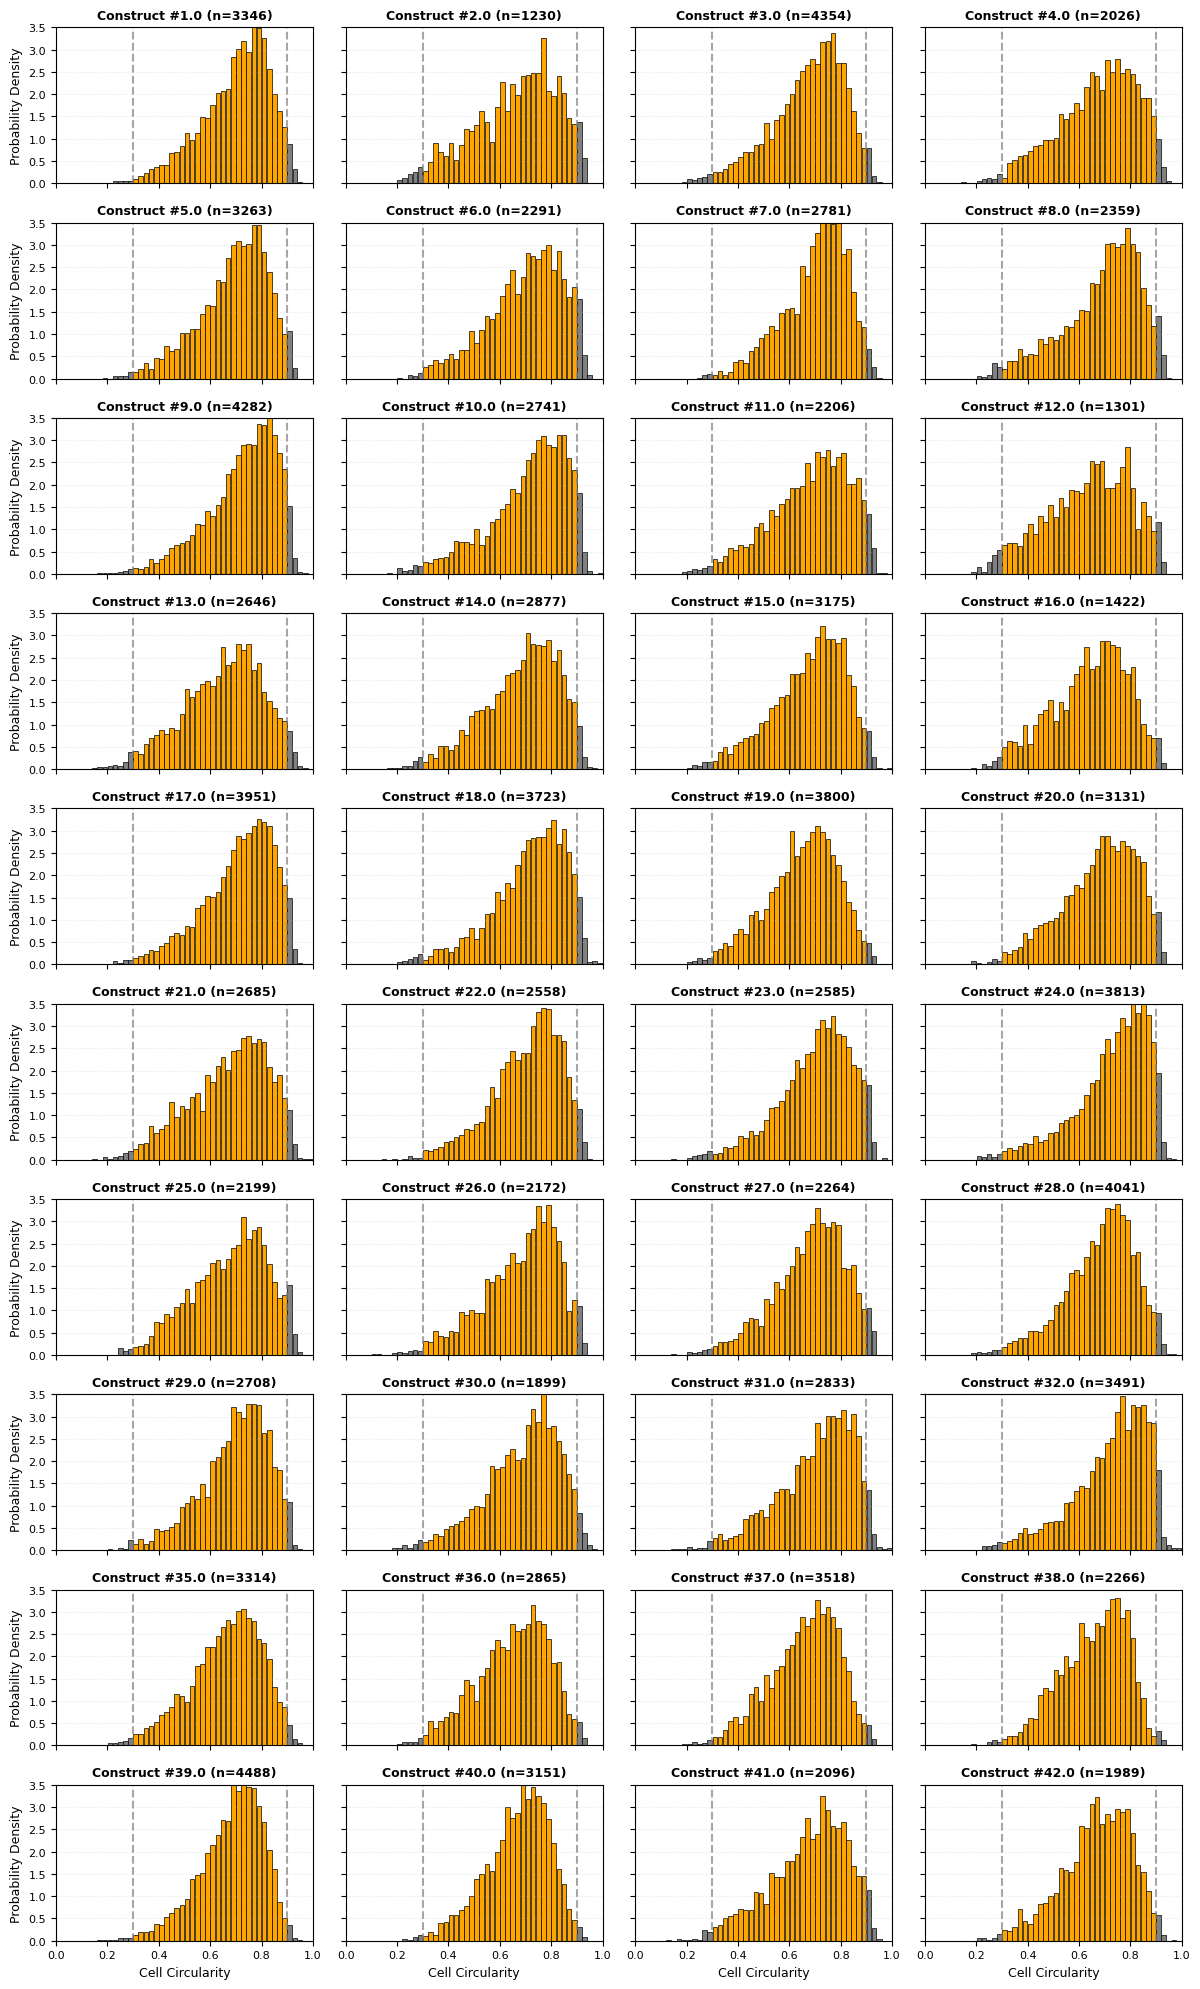

In [6]:
plot_filter_histograms(df, column='circ_cell_original', bins=50, xlim=(0, 1), ylim=(0, 3.5),
                       filter_range=(.3, .9), color='orange', figsize_per_plot=(3, 2),
                       xlabel='Cell Circularity', ylabel='Count', ncols=4, normalize=True)

(<Figure size 1200x2000 with 40 Axes>,
 array([<Axes: title={'center': 'Construct #1.0 (n=3346)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #2.0 (n=1230)'}>,
        <Axes: title={'center': 'Construct #3.0 (n=4354)'}>,
        <Axes: title={'center': 'Construct #4.0 (n=2026)'}>,
        <Axes: title={'center': 'Construct #5.0 (n=3263)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #6.0 (n=2291)'}>,
        <Axes: title={'center': 'Construct #7.0 (n=2781)'}>,
        <Axes: title={'center': 'Construct #8.0 (n=2359)'}>,
        <Axes: title={'center': 'Construct #9.0 (n=4282)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #10.0 (n=2741)'}>,
        <Axes: title={'center': 'Construct #11.0 (n=2206)'}>,
        <Axes: title={'center': 'Construct #12.0 (n=1301)'}>,
        <Axes: title={'center': 'Construct #13.0 (n=2646)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #

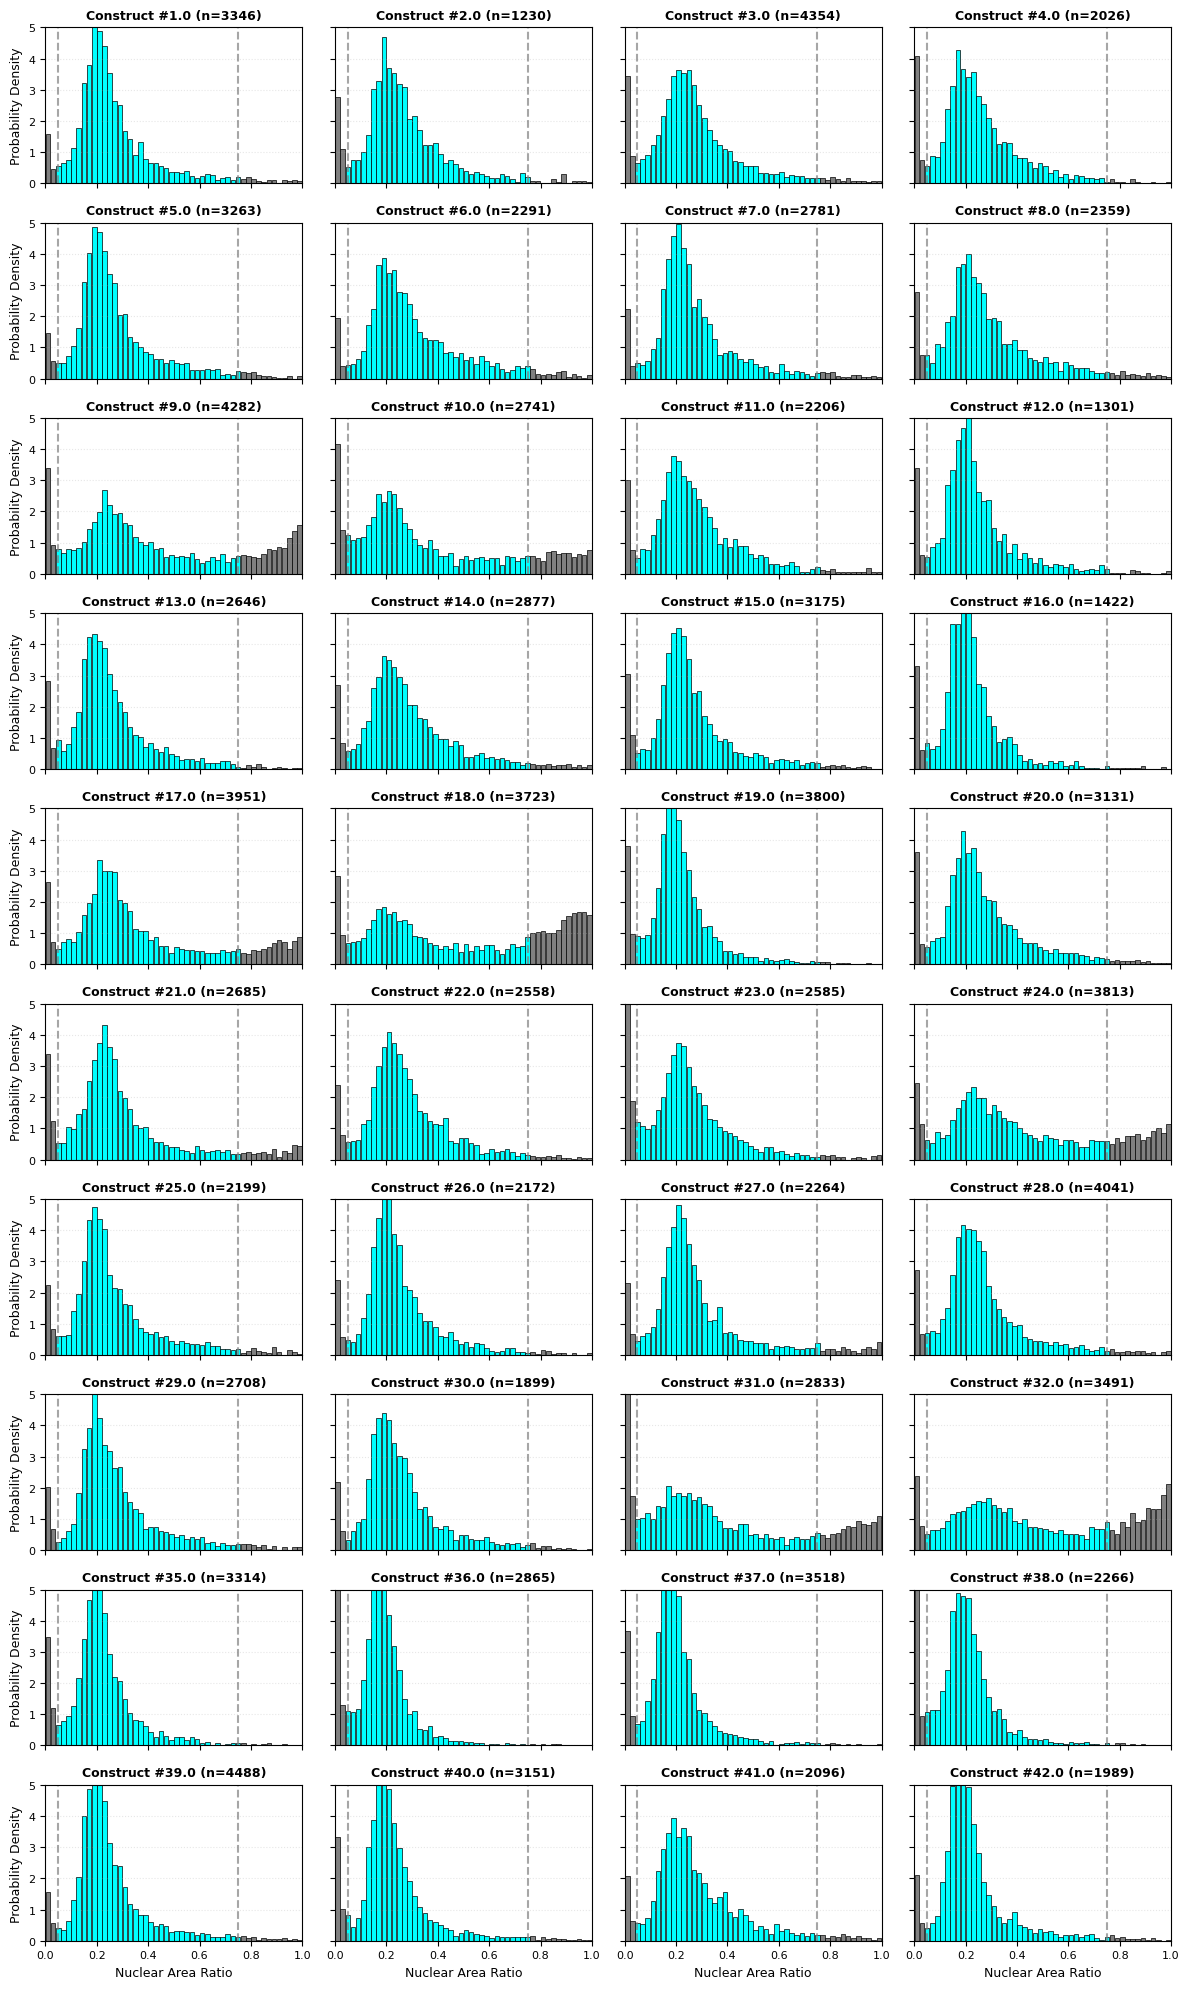

In [7]:
plot_filter_histograms(df, column='nuc_area_ratio', bins=50, xlim=(0, 1), ylim=(0, 5),
                       filter_range=(0.05, .75), color='cyan', figsize_per_plot=(3, 2),
                       xlabel='Nuclear Area Ratio', ylabel='Count', ncols=4, normalize=True)

(<Figure size 1200x2000 with 40 Axes>,
 array([<Axes: title={'center': 'Construct #1.0 (n=3346)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #2.0 (n=1230)'}>,
        <Axes: title={'center': 'Construct #3.0 (n=4354)'}>,
        <Axes: title={'center': 'Construct #4.0 (n=2026)'}>,
        <Axes: title={'center': 'Construct #5.0 (n=3263)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #6.0 (n=2291)'}>,
        <Axes: title={'center': 'Construct #7.0 (n=2781)'}>,
        <Axes: title={'center': 'Construct #8.0 (n=2359)'}>,
        <Axes: title={'center': 'Construct #9.0 (n=4282)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #10.0 (n=2741)'}>,
        <Axes: title={'center': 'Construct #11.0 (n=2206)'}>,
        <Axes: title={'center': 'Construct #12.0 (n=1301)'}>,
        <Axes: title={'center': 'Construct #13.0 (n=2646)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #

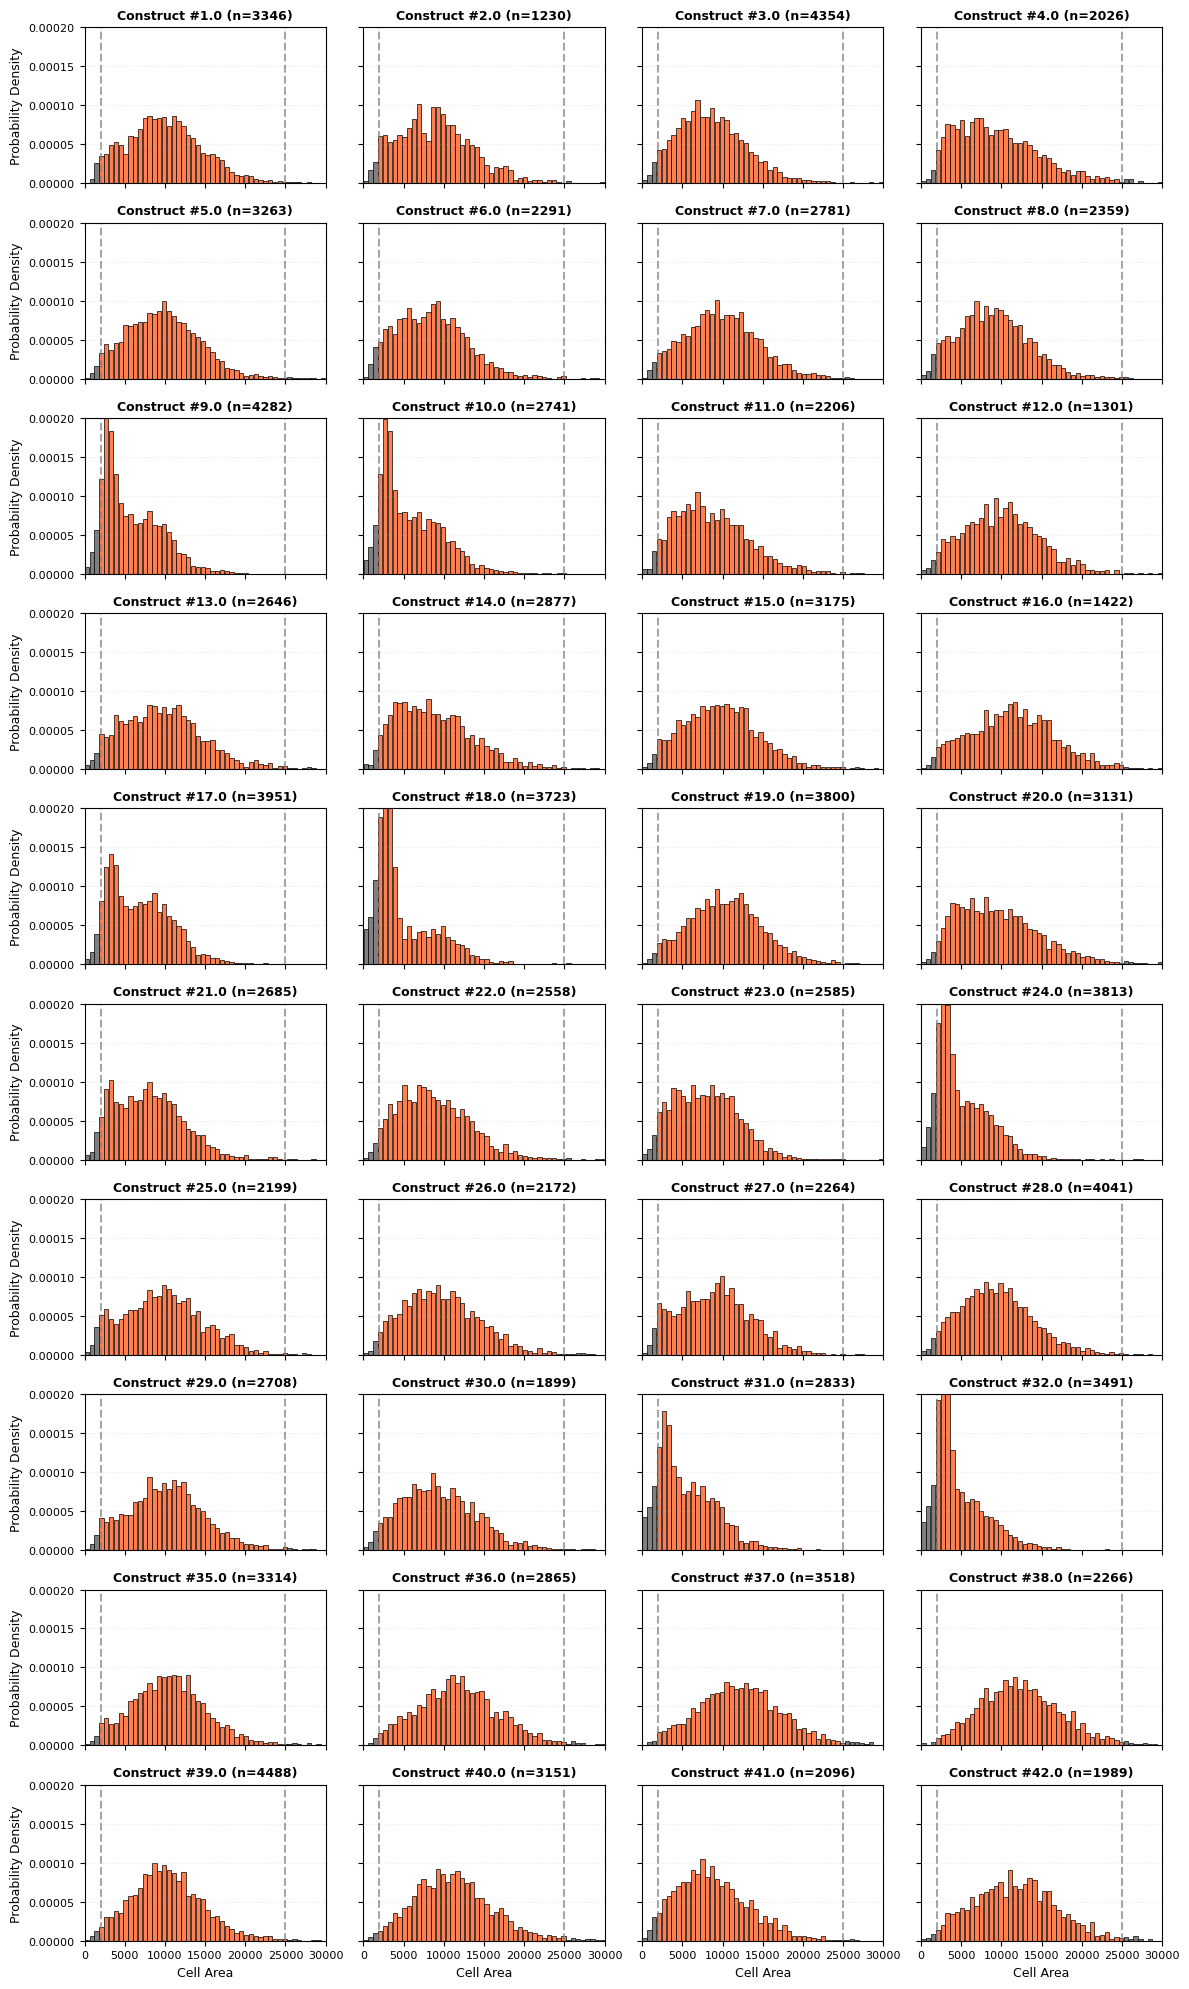

In [8]:
plot_filter_histograms(df, column='area_cell_original', bins=50, xlim=(0, 30000), ylim=(0, .0002),
                       filter_range=(2000, 25000), color='coral', figsize_per_plot=(3, 2),
                       xlabel='Cell Area', ylabel='Count', ncols=4, normalize=True)

(<Figure size 1200x2000 with 40 Axes>,
 array([<Axes: title={'center': 'Construct #1.0 (n=3346)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #2.0 (n=1230)'}>,
        <Axes: title={'center': 'Construct #3.0 (n=4354)'}>,
        <Axes: title={'center': 'Construct #4.0 (n=2026)'}>,
        <Axes: title={'center': 'Construct #5.0 (n=3263)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #6.0 (n=2291)'}>,
        <Axes: title={'center': 'Construct #7.0 (n=2781)'}>,
        <Axes: title={'center': 'Construct #8.0 (n=2359)'}>,
        <Axes: title={'center': 'Construct #9.0 (n=4282)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #10.0 (n=2741)'}>,
        <Axes: title={'center': 'Construct #11.0 (n=2206)'}>,
        <Axes: title={'center': 'Construct #12.0 (n=1301)'}>,
        <Axes: title={'center': 'Construct #13.0 (n=2646)'}, ylabel='Probability Density'>,
        <Axes: title={'center': 'Construct #

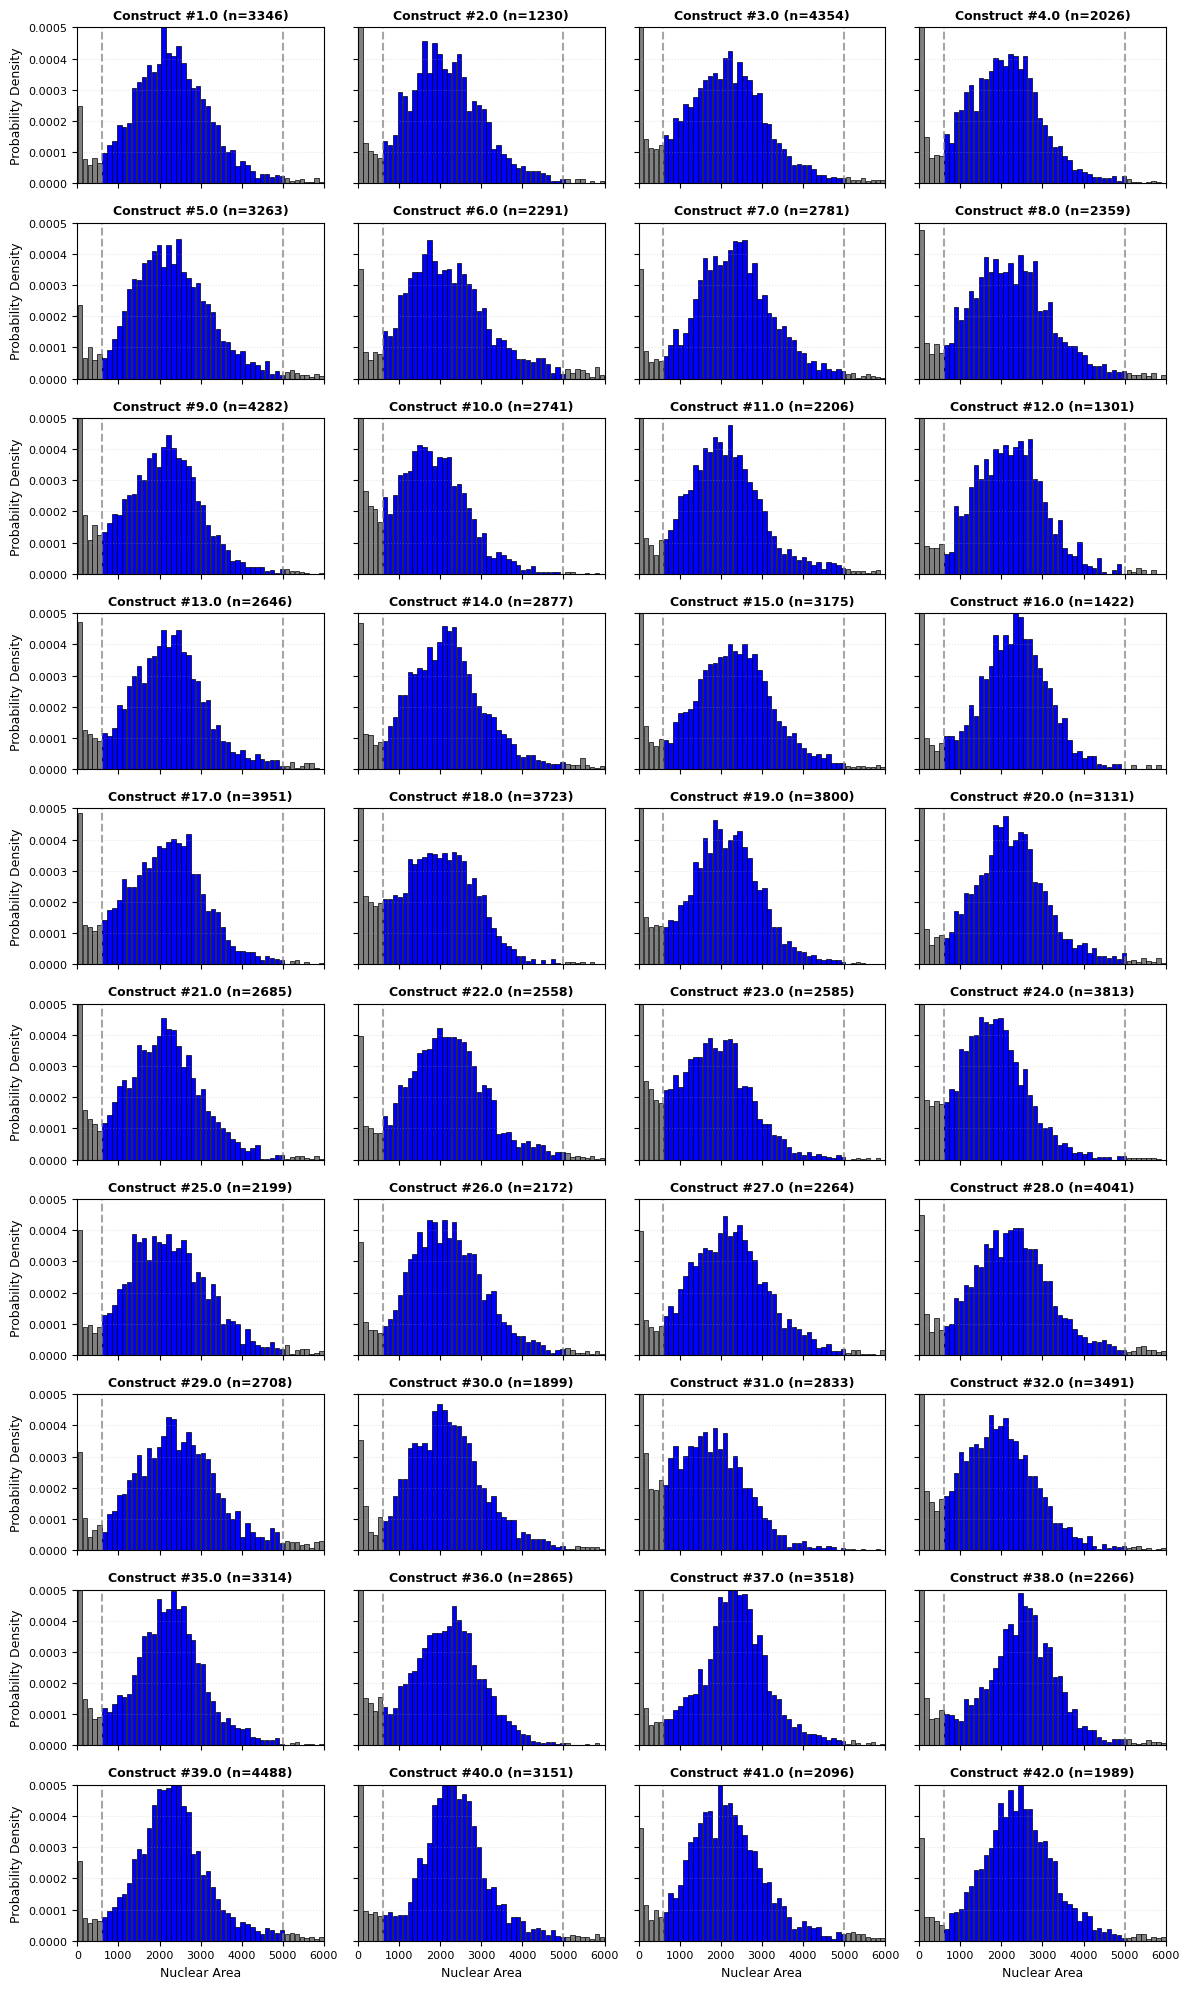

In [9]:
plot_filter_histograms(df, column='area_nuc', bins=50, xlim=(0, 6000), ylim=(0, .0005),
                       filter_range=(600, 5000), color='blue', figsize_per_plot=(3, 2),
                       xlabel='Nuclear Area', ylabel='Count', ncols=4, normalize=True)

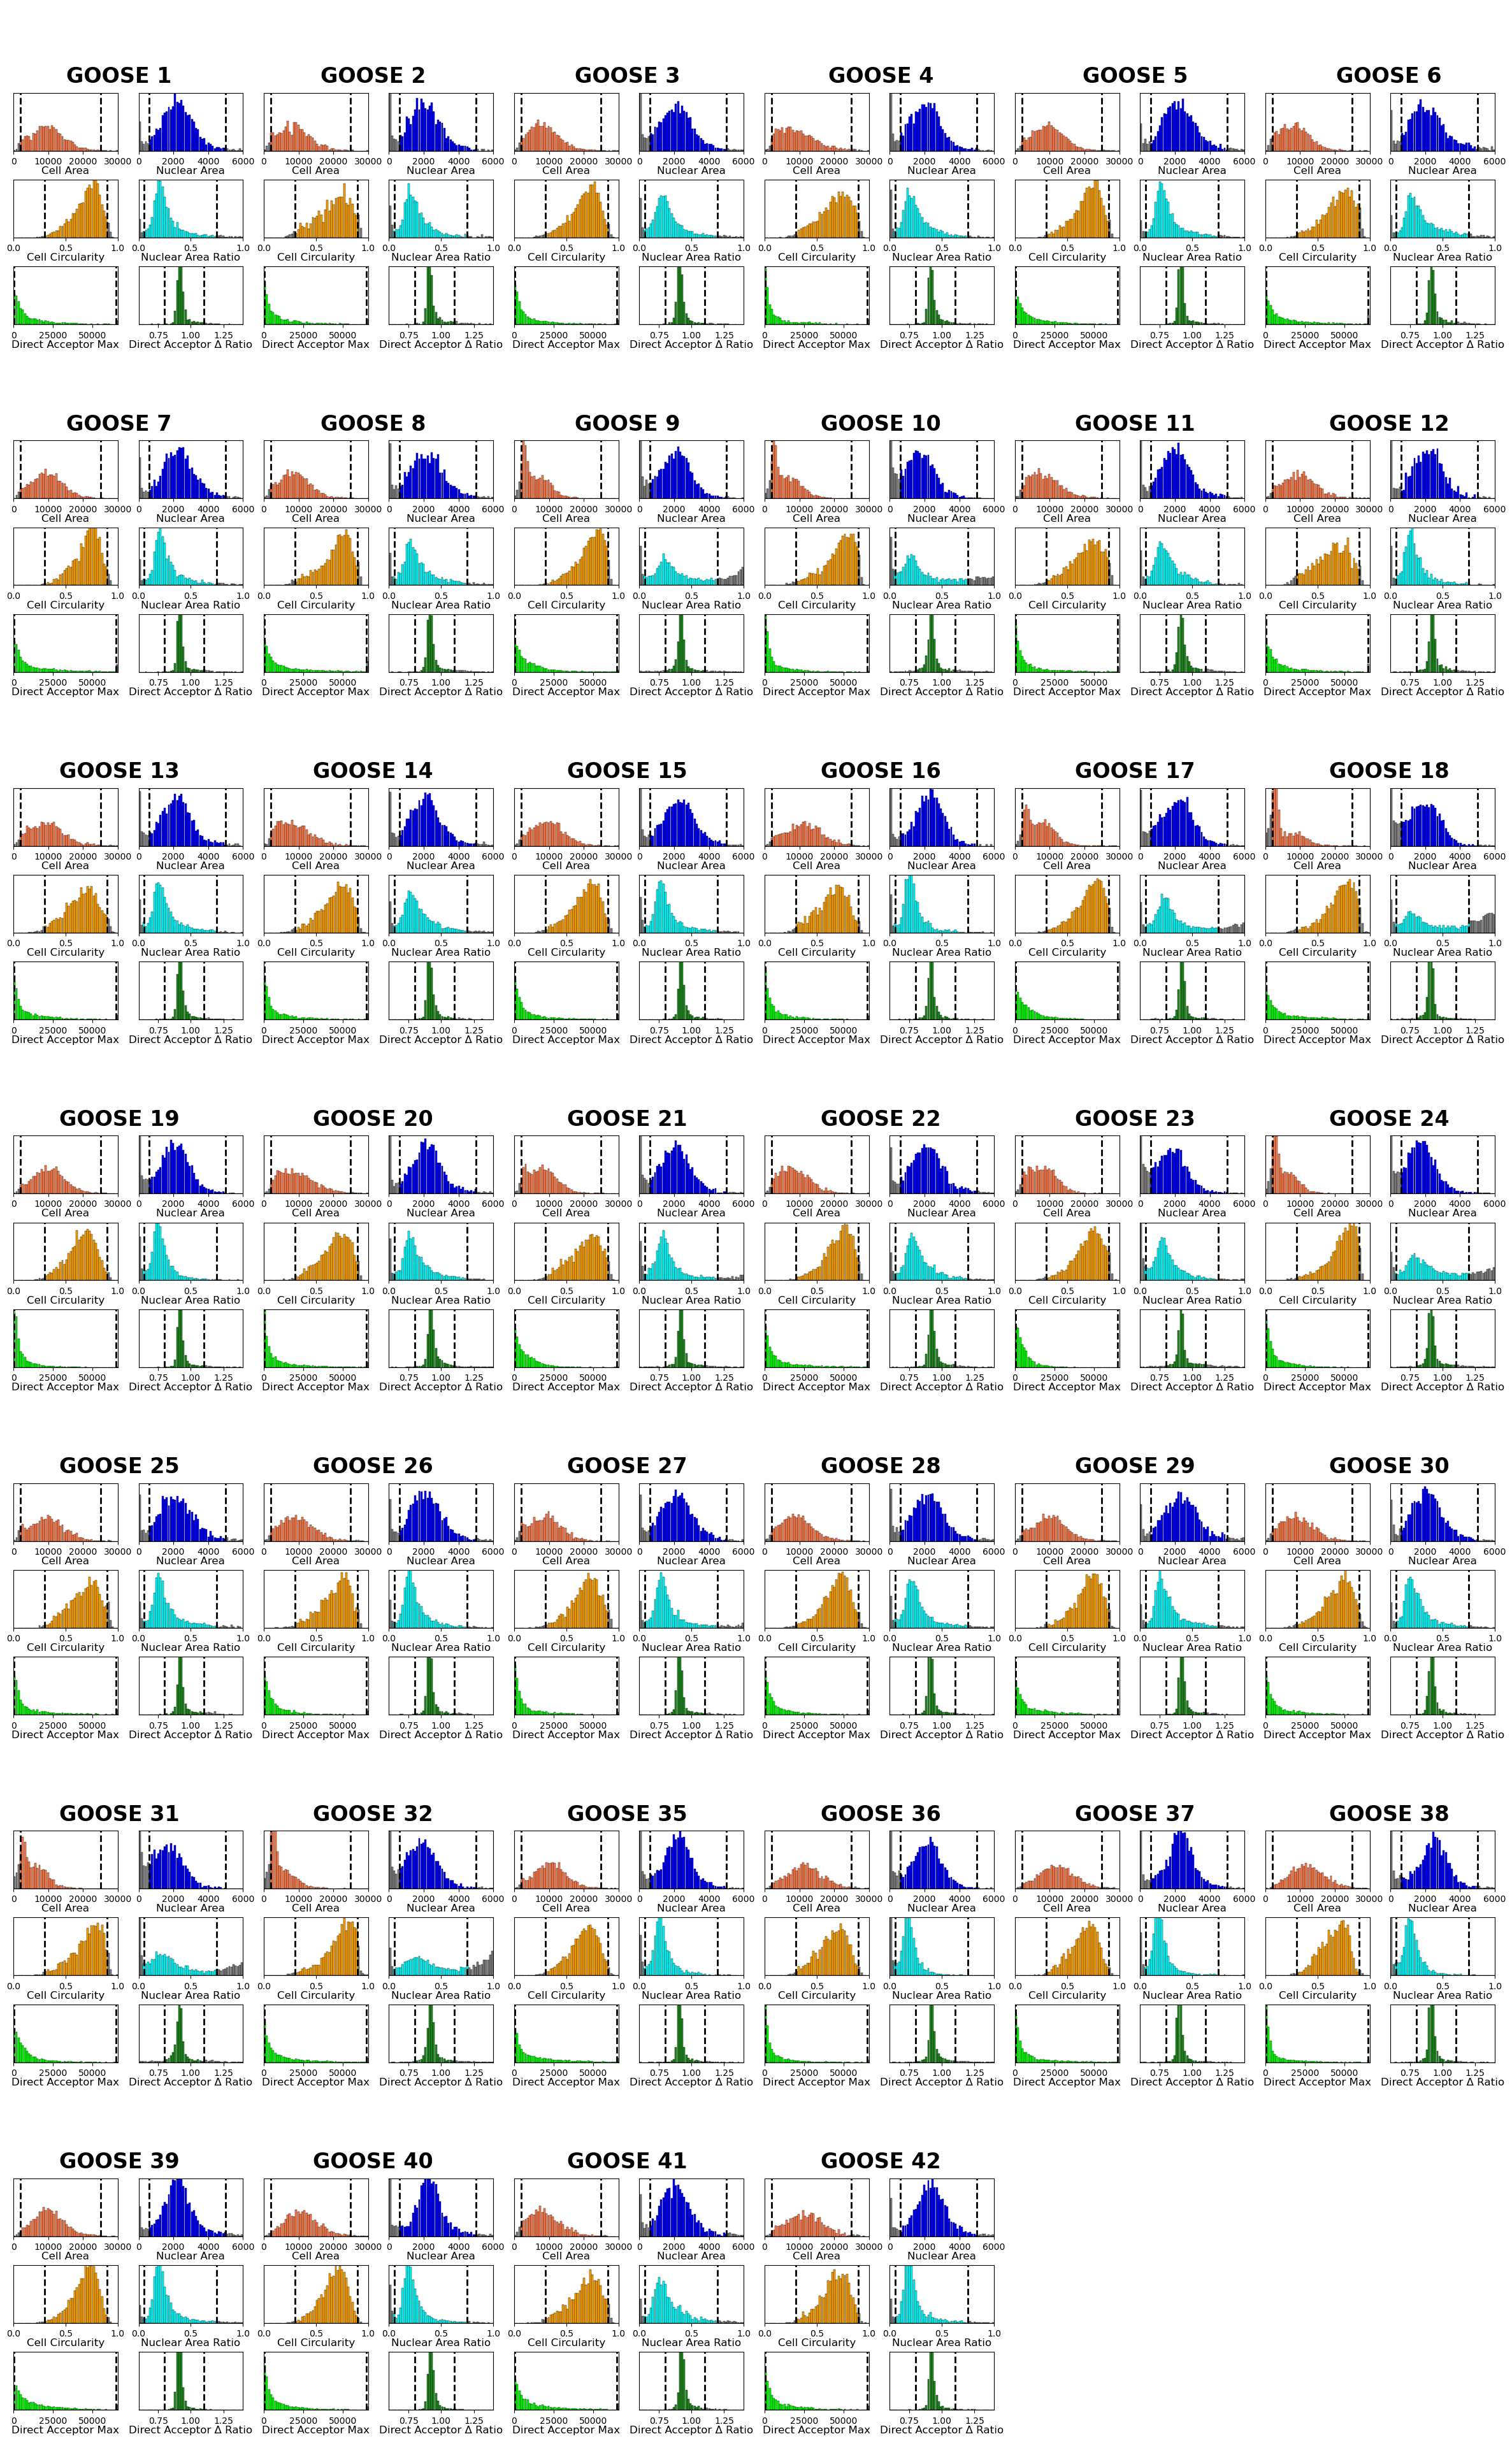

In [12]:
# Create a large figure with all constructs
constructs = sorted(df['construct'].unique())
n_constructs = len(constructs)

# Calculate grid: each construct gets 3 rows (for 3x2 mini plots) + 1 label row
# Let's do 4 constructs per "row block"
constructs_per_row = 6
n_row_blocks = math.ceil(n_constructs / constructs_per_row)

# Each construct needs 4 rows: 1 for label + 3 for the 3x2 grid of histograms
rows_per_construct_block = 4
total_rows = n_row_blocks * rows_per_construct_block

fig = plt.figure(figsize=(30, 7 * n_row_blocks))

# Define the 6 filter parameters
filters = [
    {'column': 'area_cell_original', 'bins': 50, 'xlim': (0, 30000), 'ylim': (0, .0002),
     'filter_range': (2000, 25000), 'color': 'coral', 'xlabel': 'Cell Area', 'normalize': True},
    {'column': 'area_nuc', 'bins': 50, 'xlim': (0, 6000), 'ylim': (0, .0005),
     'filter_range': (600, 5000), 'color': 'blue', 'xlabel': 'Nuclear Area', 'normalize': True},
    {'column': 'circ_cell_original', 'bins': 50, 'xlim': (0, 1), 'ylim': (0, 3.5),
     'filter_range': (.3, .9), 'color': 'orange', 'xlabel': 'Cell Circularity', 'normalize': True},
    {'column': 'nuc_area_ratio', 'bins': 50, 'xlim': (0, 1), 'ylim': (0, 5),
     'filter_range': (0.05, .75), 'color': 'cyan', 'xlabel': 'Nuclear Area Ratio', 'normalize': True},
    {'column': 'directA_cell_max', 'bins': 50, 'xlim': (0, 66000), 'ylim': (0, .0002),
     'filter_range': (400, 65000), 'color': 'lime', 'xlabel': 'Direct Acceptor Max', 'normalize': True},
    {'column': 'directA_cell_delta_ratio', 'bins': 50, 'xlim': (.6, 1.4), 'ylim': (0, 12),
     'filter_range': (0.8, 1.1), 'color': 'forestgreen', 'xlabel': 'Direct Acceptor Δ Ratio', 'normalize': True},
]

# Loop through each construct
for construct_idx, construct in enumerate(constructs):
    # Calculate which row block this construct belongs to
    row_block = construct_idx // constructs_per_row
    col_in_block = construct_idx % constructs_per_row
    
    # Starting row for this construct (each block is 4 rows tall)
    start_row = row_block * rows_per_construct_block
    
    # Add construct label at the top
    ax_label = plt.subplot2grid((total_rows, constructs_per_row), 
                                (start_row, col_in_block), fig=fig)
    # Move title closer to plots by adjusting vertical alignment to bottom
    ax_label.text(0.5, -0.4, f'GOOSE {int(construct)}', 
                  ha='center', va='bottom', fontsize=24, fontweight='bold')
    ax_label.axis('off')
    
    # Get data for this construct
    construct_data = df[df['construct'] == construct]
    
    # Loop through each filter (6 mini subplots in 3x2 grid)
    for filter_idx, filter_params in enumerate(filters):
        mini_row = filter_idx // 2  # 0, 0, 1, 1, 2, 2
        mini_col = filter_idx % 2   # 0, 1, 0, 1, 0, 1
        
        # Create subplot in a finer grid (triple the columns for spacing between constructs)
        # This adds padding columns between each construct's pair of mini-plots
        ax = plt.subplot2grid((total_rows, constructs_per_row * 2), 
                             (start_row + 1 + mini_row, col_in_block * 2 + mini_col), 
                             fig=fig)
        
        # Get column data
        column = filter_params['column']
        data = construct_data[column].dropna()
        
        if len(data) > 0:
            # Calculate histogram
            bins = filter_params['bins']
            xlim = filter_params['xlim']
            
            if xlim is not None:
                bin_edges = np.linspace(xlim[0], xlim[1], bins + 1)
            else:
                bin_edges = np.linspace(data.min(), data.max(), bins + 1)
            
            counts, edges = np.histogram(data, bins=bin_edges, 
                                        density=filter_params['normalize'])
            bin_centers = (edges[:-1] + edges[1:]) / 2
            bin_width = edges[1] - edges[0]
            
            # Determine colors
            filter_range = filter_params.get('filter_range')
            if filter_range is not None:
                left, right = filter_range
                bar_colors = [filter_params['color'] if left <= bc <= right else 'grey' 
                            for bc in bin_centers]
            else:
                bar_colors = [filter_params['color']] * len(counts)
            
            # Plot bars
            ax.bar(bin_centers, counts, width=bin_width * 0.9, 
                  color=bar_colors, edgecolor='black', linewidth=0.3)
            
            # Add dashed lines
            if filter_range is not None:
                left, right = filter_range
                ax.axvline(left, color='black', linestyle='--', linewidth=2, alpha=1)
                ax.axvline(right, color='black', linestyle='--', linewidth=2, alpha=1)
            
            # Set limits
            if xlim is not None:
                ax.set_xlim(xlim)
            if filter_params['ylim'] is not None:
                ax.set_ylim(filter_params['ylim'])
            
            # Add labels
            ax.set_xlabel(filter_params['xlabel'], fontsize=12, labelpad=0)
            ax.set_ylabel('')
            # Remove y-axis tick marks and labels
            ax.set_yticks([])
            ax.tick_params(labelsize=10)
            ax.grid(True, linestyle=':', alpha=0.3, axis='y')
            
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=8)
            ax.set_xlim(filter_params['xlim'])
            ax.set_ylim(filter_params['ylim'])
            # Remove y-axis tick marks and labels for empty plots too
            ax.set_yticks([])

# Adjust spacing: reduce vertical space between row blocks, keep horizontal spacing
plt.subplots_adjust(hspace=.5)
#plt.subplots_adjust(wspace=0, hspace = .1)
#plt.savefig('Figure_graphs/FigSI/Figure_SI_FilterDisplays.svg', bbox_inches='tight')

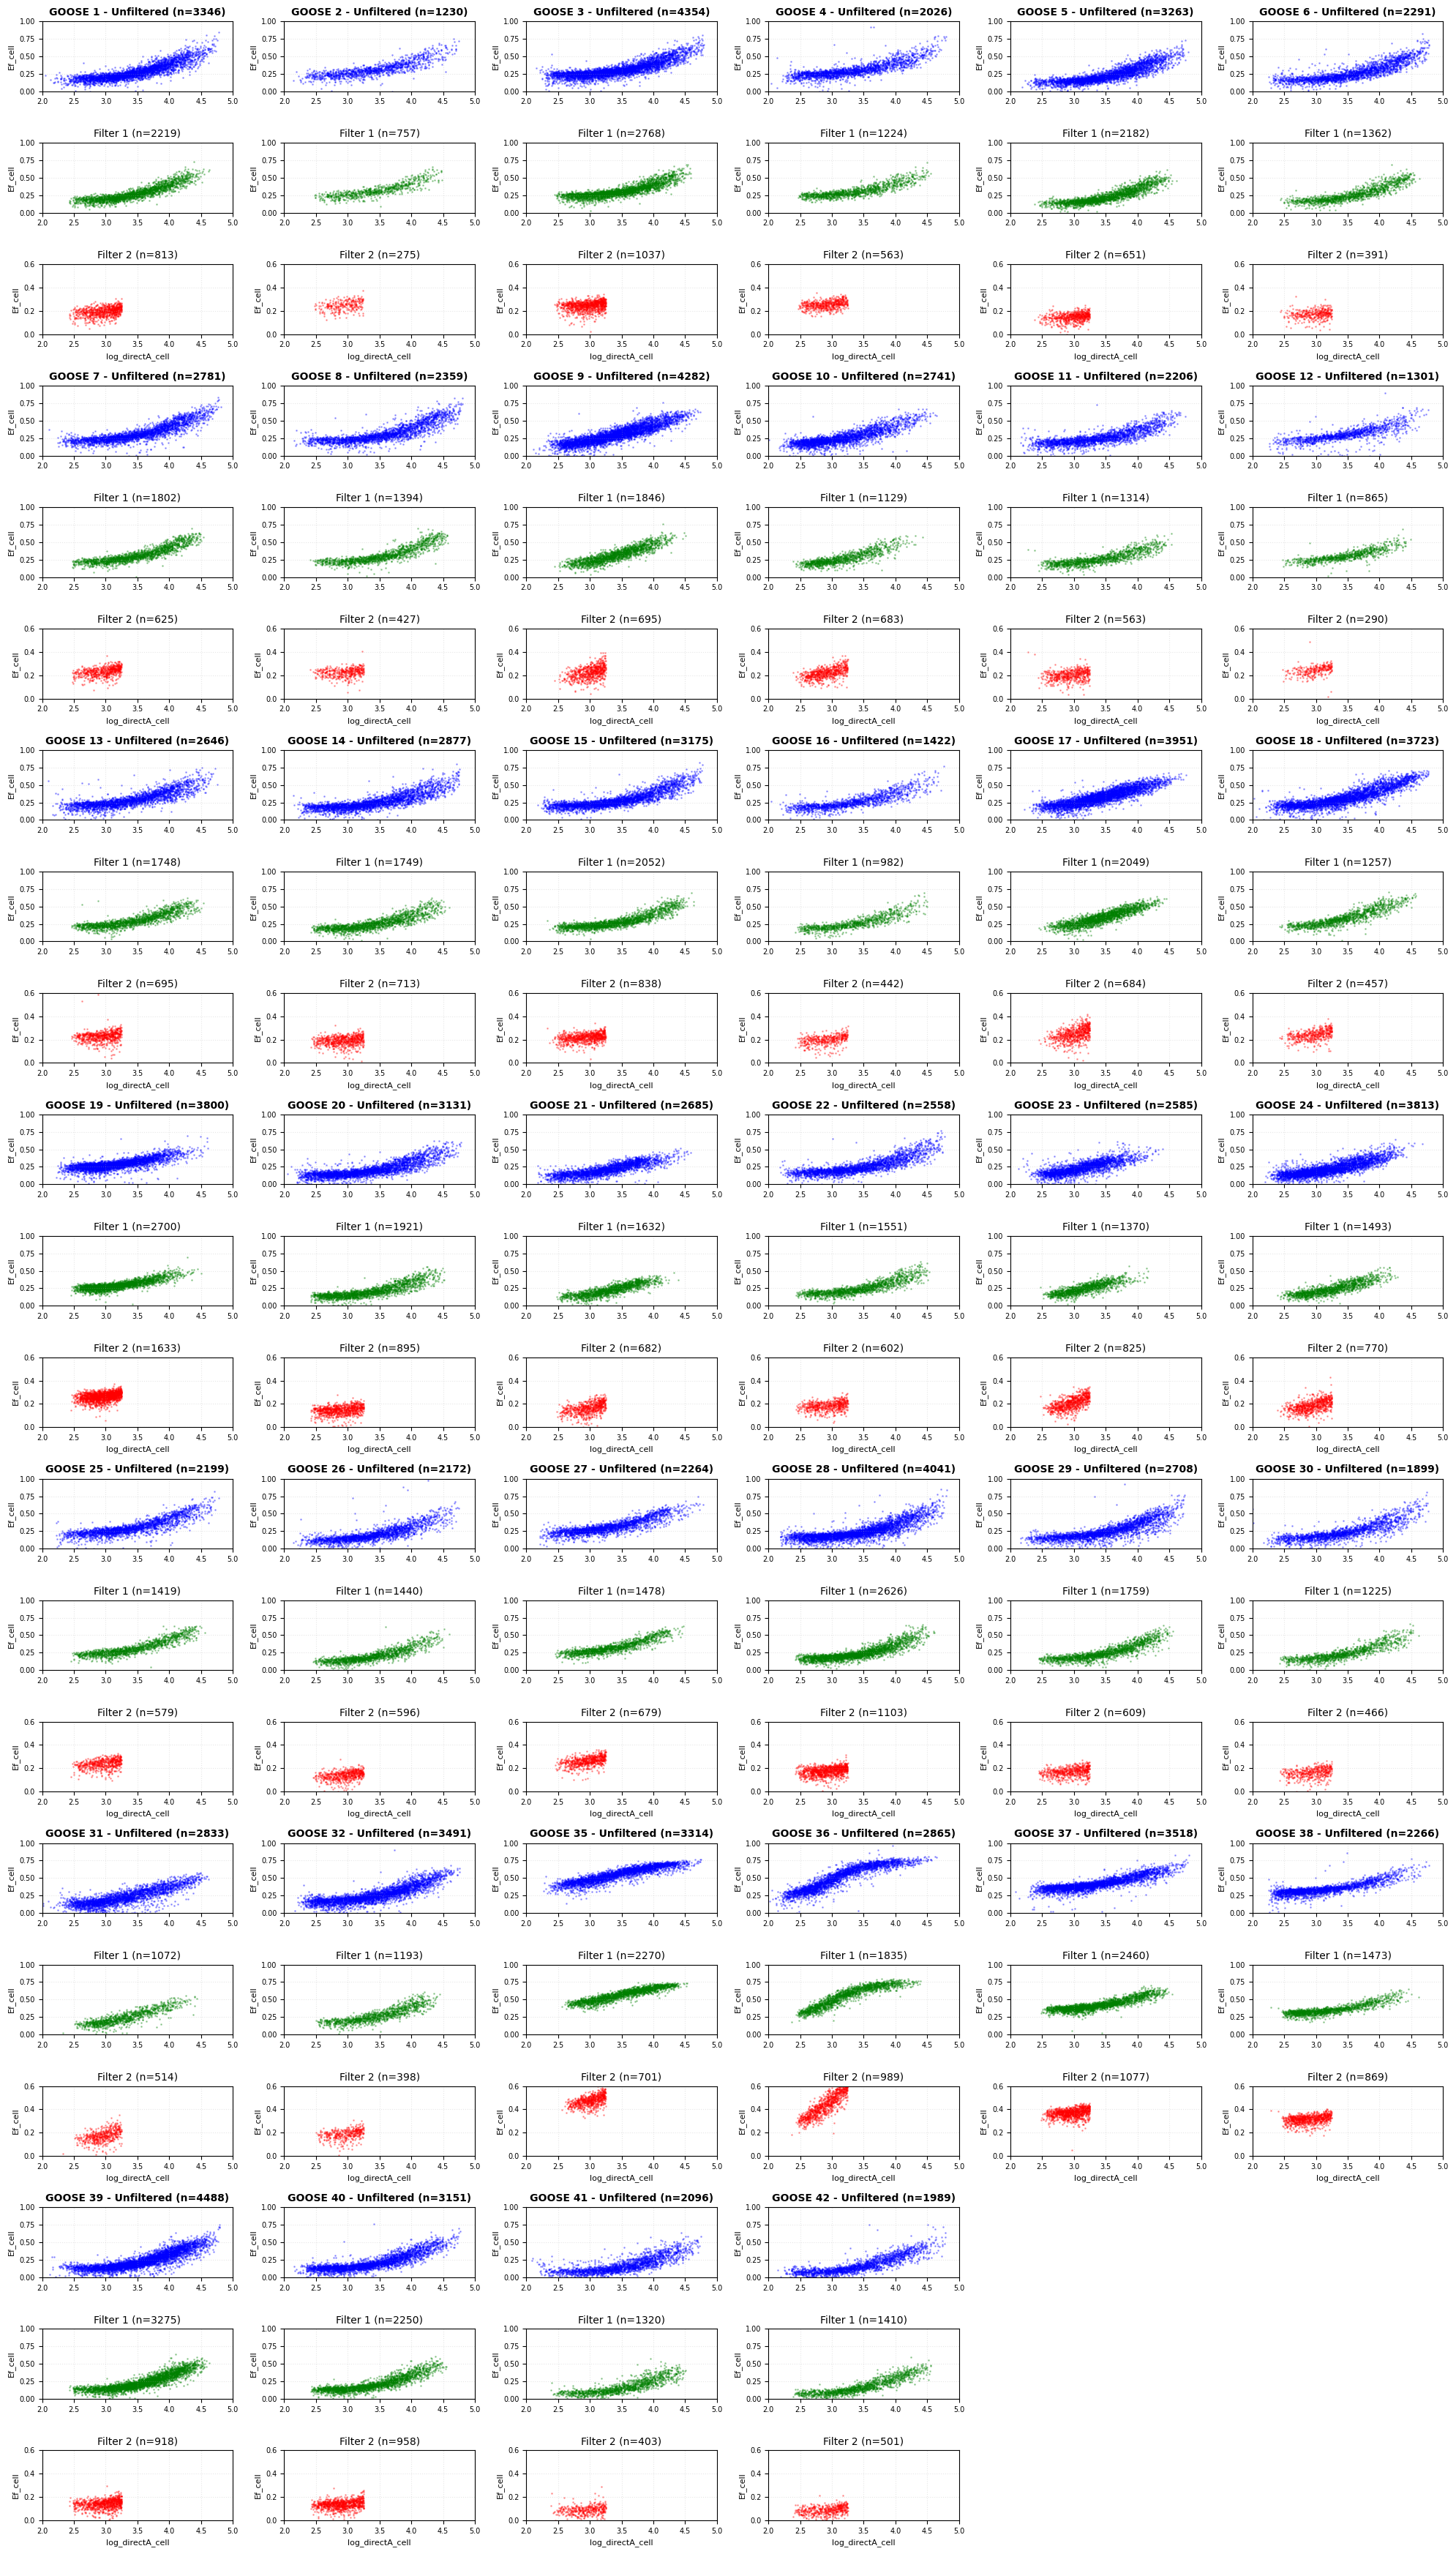

In [19]:
# Create a large figure with all constructs showing filtering progression
constructs = sorted(df['construct'].unique())
n_constructs = len(constructs)

# Calculate grid dimensions for construct layout
constructs_per_row = 6
n_row_blocks = math.ceil(n_constructs / constructs_per_row)

# Each construct needs 3 rows for the 3 filtering stages
rows_per_construct = 3
total_rows = n_row_blocks * rows_per_construct

# Create figure
fig = plt.figure(figsize=(20, 5 * n_row_blocks))

# Loop through each construct
for construct_idx, construct in enumerate(constructs):
    # Calculate position in overall grid
    row_block = construct_idx // constructs_per_row
    col_in_block = construct_idx % constructs_per_row
    
    # Starting row for this construct
    start_row = row_block * rows_per_construct
    
    # Get data for this construct
    construct_data = df[df['construct'] == construct].copy()
    
    # --- SUBPLOT 1: Unfiltered data ---
    ax1 = plt.subplot2grid((total_rows, constructs_per_row), 
                          (start_row, col_in_block), fig=fig)
    
    if len(construct_data) > 0:
        ax1.scatter(construct_data['log_directA_cell'], construct_data['Ef_cell'], 
                   s=1, alpha=0.3, c='blue')
        ax1.set_xlim(2, 5)
        ax1.set_ylim(0, 1)
        ax1.set_title(f'GOOSE {int(construct)} - Unfiltered (n={len(construct_data)})', 
                     fontsize=10, fontweight='bold')
    else:
        ax1.text(0.5, 0.5, 'No data', ha='center', va='center', 
                transform=ax1.transAxes, fontsize=10)
        ax1.set_xlim(2, 5)
        ax1.set_ylim(0, 1)
        ax1.set_title(f'GOOSE {int(construct)} - Unfiltered', 
                     fontsize=10, fontweight='bold')
    
    ax1.set_ylabel('Ef_cell', fontsize=8)
    ax1.tick_params(labelsize=7)
    ax1.grid(True, linestyle=':', alpha=0.3)
    
    # --- Apply Filter 1 ---
    filtered_data = construct_data[
        (construct_data['directA_cell_max'] >= 400) &
        (construct_data['directA_cell_max'] <= 65000) &
        (construct_data['directA_cell_delta_ratio'] > 0.8) &
        (construct_data['directA_cell_delta_ratio'] < 1.1) &
        (construct_data['circ_cell_original'] < 0.8) &
        (construct_data['circ_cell_original'] > 0.3) &
        (construct_data['nuc_area_ratio'] < 0.75) &
        (construct_data['nuc_area_ratio'] > 0.05) &
        (construct_data['A_cell_corr'] > 0) &
        (construct_data['area_cell'] > 2000) &
        (construct_data['area_cell'] < 25000) &
        (construct_data['area_nuc'] < 5000) &
        (construct_data['area_nuc'] > 600)
    ].copy()
    
    # --- SUBPLOT 2: Filter 1 applied ---
    ax2 = plt.subplot2grid((total_rows, constructs_per_row), 
                          (start_row + 1, col_in_block), fig=fig, sharex=ax1)
    
    if len(filtered_data) > 0:
        ax2.scatter(filtered_data['log_directA_cell'], filtered_data['Ef_cell'], 
                   s=1, alpha=0.3, c='green')
        ax2.set_xlim(2, 5)
        ax2.set_ylim(0, 1)
        ax2.set_title(f'Filter 1 (n={len(filtered_data)})', fontsize=10)
    else:
        ax2.text(0.5, 0.5, 'No data', ha='center', va='center', 
                transform=ax2.transAxes, fontsize=10)
        ax2.set_xlim(2, 5)
        ax2.set_ylim(0, 1)
        ax2.set_title('Filter 1', fontsize=10)
    
    ax2.set_ylabel('Ef_cell', fontsize=8)
    ax2.tick_params(labelsize=7)
    ax2.grid(True, linestyle=':', alpha=0.3)
    
    # --- Apply Filter 2 ---
    filtered_data2 = filtered_data[
        (filtered_data['log_directA_cell'] < 3.25) &
        (filtered_data['log_directA_cell'] > 2)
    ].copy()
    
    # --- SUBPLOT 3: Filter 2 applied ---
    ax3 = plt.subplot2grid((total_rows, constructs_per_row), 
                          (start_row + 2, col_in_block), fig=fig, sharex=ax1)
    
    if len(filtered_data2) > 0:
        ax3.scatter(filtered_data2['log_directA_cell'], filtered_data2['Ef_cell'], 
                   s=1, alpha=0.3, c='red')
        ax3.set_xlim(2, 5)
        ax3.set_ylim(0, 0.6)
        ax3.set_title(f'Filter 2 (n={len(filtered_data2)})', fontsize=10)
    else:
        ax3.text(0.5, 0.5, 'No data', ha='center', va='center', 
                transform=ax3.transAxes, fontsize=10)
        ax3.set_xlim(2.3, 3.3)
        ax3.set_ylim(0, 0.6)
        ax3.set_title('Filter 2', fontsize=10)
    
    ax3.set_xlabel('log_directA_cell', fontsize=8)
    ax3.set_ylabel('Ef_cell', fontsize=8)
    ax3.tick_params(labelsize=7)
    ax3.grid(True, linestyle=':', alpha=0.3)

# Adjust spacing
plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.tight_layout()
#plt.savefig('Figure_FilterProgression.png', dpi=300, bbox_inches='tight')
plt.show()

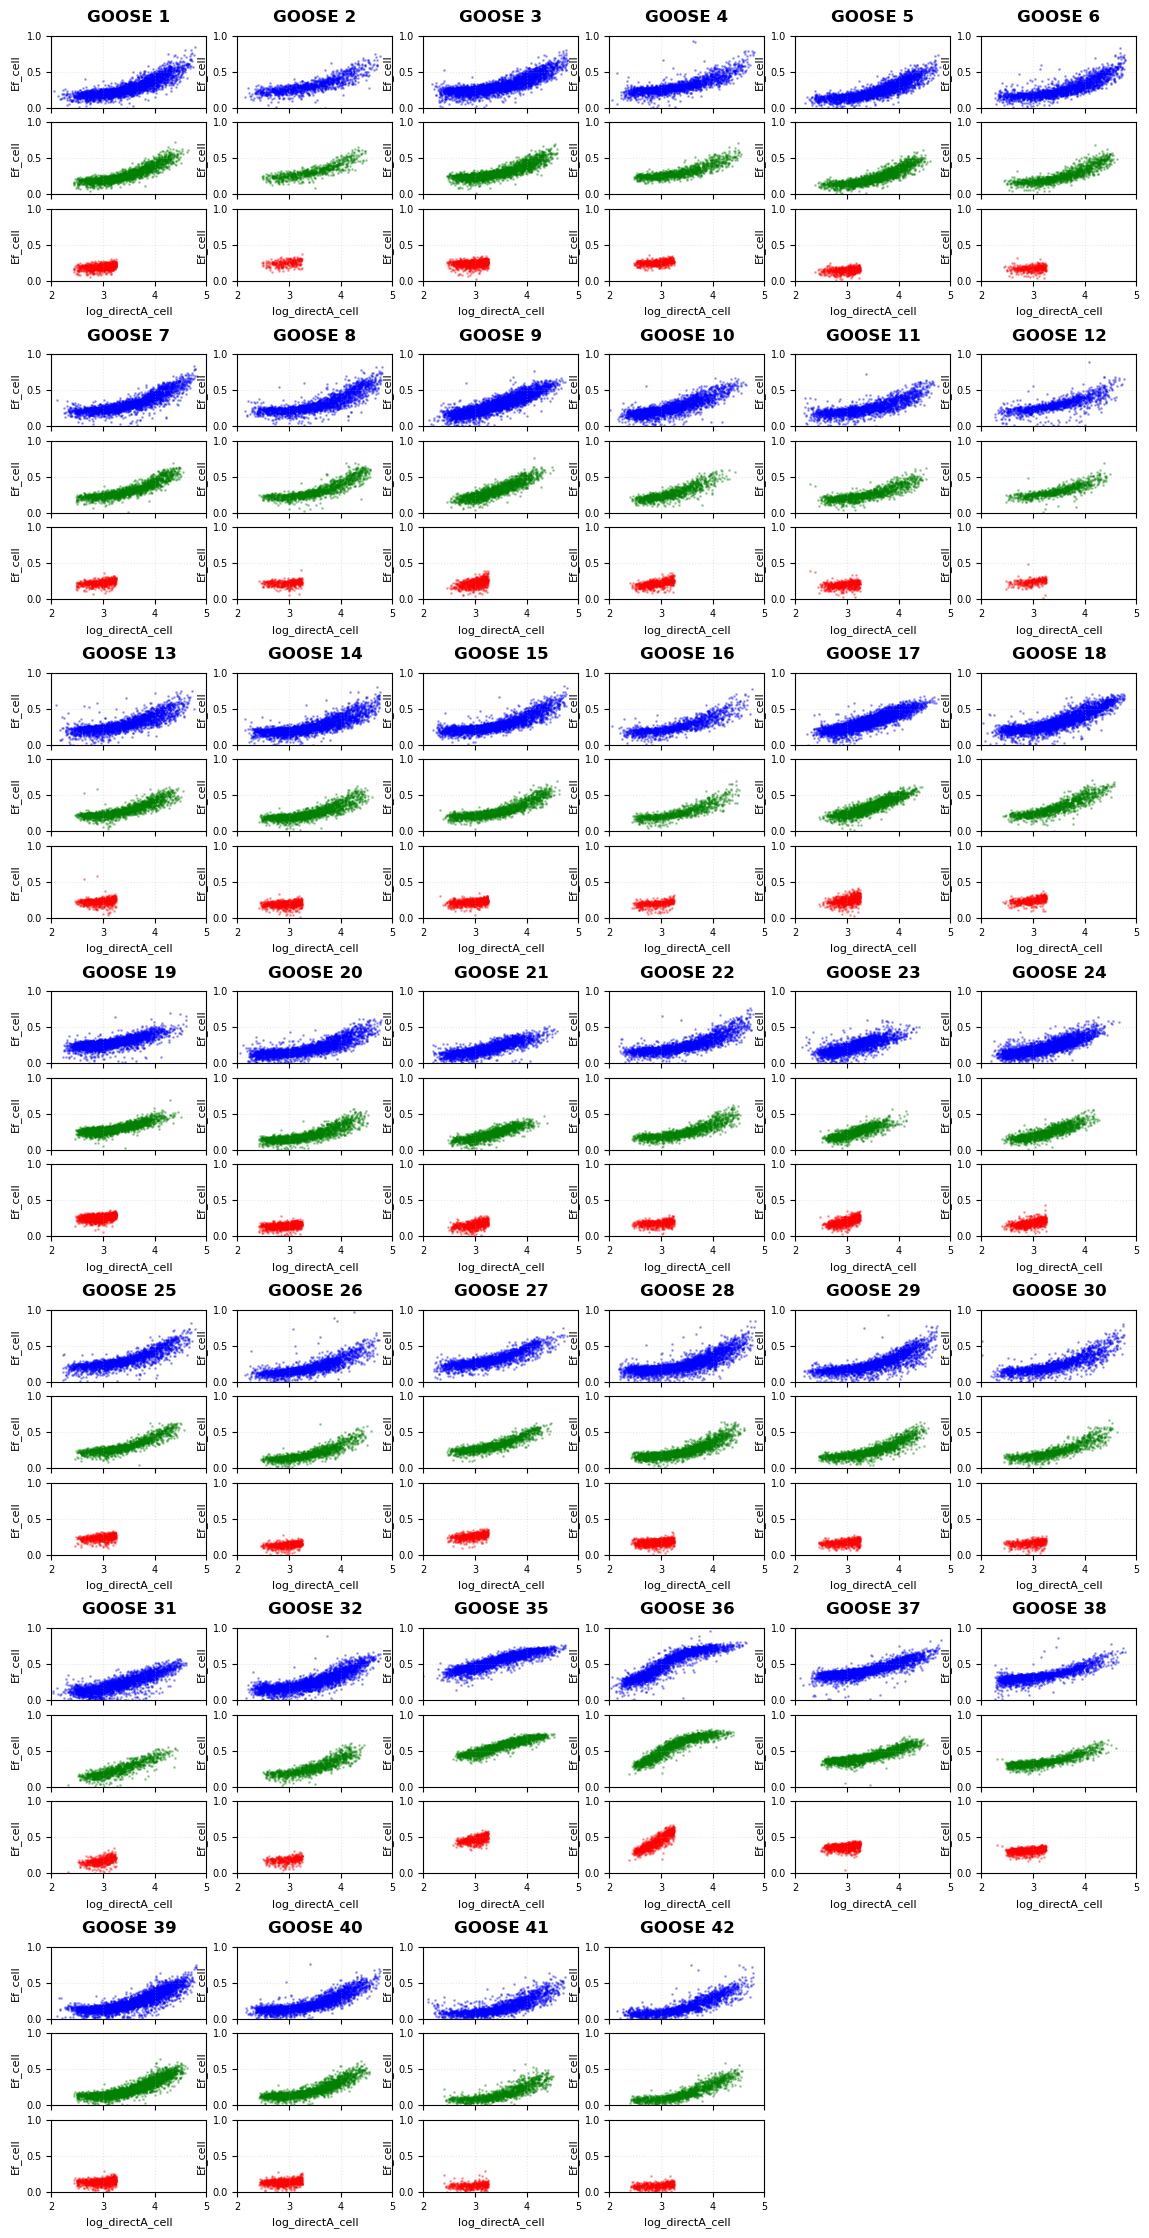

In [26]:
from matplotlib.gridspec import GridSpec

# Create a large figure with all constructs showing filtering progression
constructs = sorted(df['construct'].unique())
n_constructs = len(constructs)

# Calculate grid dimensions for construct layout
constructs_per_row = 6
n_row_blocks = math.ceil(n_constructs / constructs_per_row)

# Each construct needs 3 rows for the 3 filtering stages
rows_per_construct = 3

# Create figure
fig = plt.figure(figsize=(14, 4 * n_row_blocks))

# Create outer GridSpec for construct groups (with large spacing between constructs)
outer_gs = GridSpec(n_row_blocks, constructs_per_row, figure=fig, 
                    hspace=0.3, wspace=0.2)  # Spacing BETWEEN constructs

# Loop through each construct
for construct_idx, construct in enumerate(constructs):
    # Calculate position in overall grid
    row_block = construct_idx // constructs_per_row
    col_in_block = construct_idx % constructs_per_row
    
    # Get data for this construct
    construct_data = df[df['construct'] == construct].copy()
    
    # Create inner GridSpec for this construct's 3 subplots (with minimal spacing)
    inner_gs = outer_gs[row_block, col_in_block].subgridspec(3, 1, 
                                                              hspace=0.2)  # Minimal spacing WITHIN construct
    
    # --- SUBPLOT 1: Unfiltered data ---
    ax1 = fig.add_subplot(inner_gs[0])
    
    if len(construct_data) > 0:
        ax1.scatter(construct_data['log_directA_cell'], construct_data['Ef_cell'], 
                   s=1, alpha=0.3, c='blue')
        ax1.set_xlim(2, 5)
        ax1.set_ylim(0, 1)
    else:
        ax1.text(0.5, 0.5, 'No data', ha='center', va='center', 
                transform=ax1.transAxes, fontsize=10)
        ax1.set_xlim(2, 5)
        ax1.set_ylim(0, 1)
    
    # Add construct title only on first subplot
    ax1.set_title(f'GOOSE {int(construct)}', 
                 fontsize=12, fontweight='bold', pad=10)
    ax1.set_ylabel('Ef_cell', fontsize=8)
    ax1.tick_params(labelsize=7, labelbottom=False)  # Remove x-axis labels
    ax1.grid(True, linestyle=':', alpha=0.3)
    
    # --- Apply Filter 1 ---
    filtered_data = construct_data[
        (construct_data['directA_cell_max'] >= 400) &
        (construct_data['directA_cell_max'] <= 65000) &
        (construct_data['directA_cell_delta_ratio'] > 0.8) &
        (construct_data['directA_cell_delta_ratio'] < 1.1) &
        (construct_data['circ_cell_original'] < 0.8) &
        (construct_data['circ_cell_original'] > 0.3) &
        (construct_data['nuc_area_ratio'] < 0.75) &
        (construct_data['nuc_area_ratio'] > 0.05) &
        (construct_data['A_cell_corr'] > 0) &
        (construct_data['area_cell'] > 2000) &
        (construct_data['area_cell'] < 25000) &
        (construct_data['area_nuc'] < 5000) &
        (construct_data['area_nuc'] > 600)
    ].copy()
    
    # --- SUBPLOT 2: Filter 1 applied ---
    ax2 = fig.add_subplot(inner_gs[1], sharex=ax1)
    
    if len(filtered_data) > 0:
        ax2.scatter(filtered_data['log_directA_cell'], filtered_data['Ef_cell'], 
                   s=1, alpha=0.3, c='green')
        ax2.set_xlim(2, 5)
        ax2.set_ylim(0, 1)
    else:
        ax2.text(0.5, 0.5, 'No data', ha='center', va='center', 
                transform=ax2.transAxes, fontsize=10)
        ax2.set_xlim(2, 5)
        ax2.set_ylim(0, 1)
    
    ax2.set_ylabel('Ef_cell', fontsize=8)
    ax2.tick_params(labelsize=7, labelbottom=False)  # Remove x-axis labels
    ax2.grid(True, linestyle=':', alpha=0.3)
    
    # --- Apply Filter 2 ---
    filtered_data2 = filtered_data[
        (filtered_data['log_directA_cell'] < 3.25) &
        (filtered_data['log_directA_cell'] > 2)
    ].copy()
    
    # --- SUBPLOT 3: Filter 2 applied ---
    ax3 = fig.add_subplot(inner_gs[2], sharex=ax1)
    
    if len(filtered_data2) > 0:
        ax3.scatter(filtered_data2['log_directA_cell'], filtered_data2['Ef_cell'], 
                   s=1, alpha=0.3, c='red')
        ax3.set_xlim(2, 5)
        ax3.set_ylim(0, 1)
    else:
        ax3.text(0.5, 0.5, 'No data', ha='center', va='center', 
                transform=ax3.transAxes, fontsize=10)
        ax3.set_xlim(2, 5)
        ax3.set_ylim(0, 1)
    
    ax3.set_xlabel('log_directA_cell', fontsize=8)
    ax3.set_ylabel('Ef_cell', fontsize=8)
    ax3.tick_params(labelsize=7)  # Keep x-axis labels for bottom plot
    ax3.grid(True, linestyle=':', alpha=0.3)

#plt.savefig('Figure_FilterProgression.png', dpi=300, bbox_inches='tight')
plt.show()